In [1]:
def Auto_MSG_SE_Densenet_EfficentTemp_GAN(vy,vx,upscale,test_size=0.25,if_best_mode='no',modelpath=None,conv_core_num=512,model_deep=5,Vgg_deep=5,base_layer=16,simpleconv_deep=3,mbconv_deep=2,se_radio=0.5,if_weight_initialize='no',weight_initialize_method='TruncatedNormal',weight_initialize_parameter1=0.00,weight_initialize_parameter2=0.05,loss_function='default',if_print_model='yes',optimizer='SGD',g_learning_rate=0.001,d_learning_rate=0.01,epochs=2000,batch_size=20,g_train_time=2,ifrandom_split='yes',ifmute='no',ifsave='no',savepath=None,device='cpu'):
    import tensorflow as tf
    if device=='gpu':
        gpus = tf.config.list_physical_devices('GPU')
        if gpus:
            try:
                # 设置只使用 GPU 1
                tf.config.set_visible_devices(gpus[1], 'GPU')
                # 设置 GPU 1 的内存动态增长
                tf.config.experimental.set_memory_growth(gpus[1], True)
            except RuntimeError as e:
                print(e)
    from keras.models import Sequential,Model
    import math
    from keras.initializers import TruncatedNormal,RandomNormal,RandomUniform
    from keras.layers import BatchNormalization,LayerNormalization,LocallyConnected2D,Conv2D,MaxPooling2D,AveragePooling2D,GlobalAveragePooling2D,Input,UpSampling2D,ZeroPadding2D,UpSampling2D,Add,Flatten,Activation,Dropout,Dense,Concatenate,GlobalAveragePooling2D,Multiply,DepthwiseConv2D
    from sklearn.model_selection import train_test_split
    import numpy as np
    from tensorflow.keras.optimizers import SGD,Adam
    from scipy.stats import pearsonr
    from keras.models import load_model
    import os
    from sklearn.metrics import accuracy_score,log_loss
    import keras.backend as K
    
    vy=np.nan_to_num(vy,nan=0)
    vx=np.nan_to_num(vx,nan=0)
    if ifrandom_split=='yes':
        trainx,testx,trainy,testy = train_test_split(vx,vy,test_size=test_size,random_state=25)
    elif ifrandom_split=='no':
        index=int((1-test_size)*vy.shape[0])
        trainy=vy[:index,:,:,:]
        testy=vy[index:,:,:,:]
        trainx=vx[:index,:,:,:]
        testx=vx[index:,:,:,:]
    if device=='gpu':
        if optimizer == 'SGD':
            g_opt = SGD(lr = g_learning_rate)
            d_opt = SGD(lr = d_learning_rate)
        elif optimizer == 'Adam':
            g_opt = Adam(lr = g_learning_rate)
            d_opt = Adam(lr = d_learning_rate)
        if if_best_mode=='no':
            def build_generator(trainy,generator_input,model_deep,conv_core_num,upscale,simpleconv_deep,mbconv_deep,se_radio,if_weight_initialize,weight_initialize_parameter1,weight_initialize_parameter2):
                import tensorflow as tf
                from keras.models import Sequential,Model
                import math
                from keras.initializers import TruncatedNormal,RandomNormal,RandomUniform
                from keras.layers import BatchNormalization,LayerNormalization,LocallyConnected2D,Conv2D,MaxPooling2D,AveragePooling2D,GlobalAveragePooling2D,Input,UpSampling2D,ZeroPadding2D,UpSampling2D,Add,Flatten,Activation,Dropout,Dense,Concatenate,GlobalAveragePooling2D,Multiply,DepthwiseConv2D
                from sklearn.model_selection import train_test_split
                import numpy as np
                from tensorflow.keras.optimizers import SGD,Adam
                from scipy.stats import pearsonr
                from keras.models import load_model
                import os
                generator_inputs=Input(shape=(generator_input.shape[1],generator_input.shape[2],vx.shape[3]))
                if if_weight_initialize=='no':
                    exec('generator_conv_start_1=Conv2D(conv_core_num,(3,3),strides=1,padding="same")(generator_inputs)')
                else:
                    if weight_initialize_method=='RandomNormal':
                        exec('generator_conv_start_1=Conv2D(conv_core_num,(3,3),strides=1,padding="same",kernel_initializer = RandomNormal(mean=weight_initialize_parameter1,stddev=weight_initialize_parameter2))(generator_inputs)')
                    elif weight_initialize_method=='RandomUniform':
                        exec('generator_conv_start_1=Conv2D(conv_core_num,(3,3),strides=1,padding="same",kernel_initializer = RandomUniform(minval=weight_initialize_parameter1,maxval=weight_initialize_parameter2))(generator_inputs)')
                    elif weight_initialize_method=='TruncatedNormal':
                        exec('generator_conv_start_1=Conv2D(conv_core_num,(3,3),strides=1,padding="same",kernel_initializer = TruncatedNormal(mean=weight_initialize_parameter1,stddev=weight_initialize_parameter2))(generator_inputs)')
                exec('generator_act_start_1=Activation("leaky_relu")(generator_conv_start_1)')
                if if_weight_initialize=='no':
                    exec('generator_conv_start_2=Conv2D(conv_core_num,(3,3),strides=1,padding="same")(generator_act_start_1)')
                else:
                    if weight_initialize_method=='RandomNormal':
                        exec('generator_conv_start_2=Conv2D(conv_core_num,(3,3),strides=1,padding="same",kernel_initializer = RandomNormal(mean=weight_initialize_parameter1,stddev=weight_initialize_parameter2))(generator_act_start_1)')
                    elif weight_initialize_method=='RandomUniform':
                        exec('generator_conv_start_2=Conv2D(conv_core_num,(3,3),strides=1,padding="same",kernel_initializer = RandomUniform(minval=weight_initialize_parameter1,maxval=weight_initialize_parameter2))(generator_act_start_1)')
                    elif weight_initialize_method=='TruncatedNormal':
                        exec('generator_conv_start_2=Conv2D(conv_core_num,(3,3),strides=1,padding="same",kernel_initializer = TruncatedNormal(mean=weight_initialize_parameter1,stddev=weight_initialize_parameter2))(generator_act_start_1)')
                exec('generator_act_start_2=Activation("leaky_relu")(generator_conv_start_2)')
                exec('segap_start=GlobalAveragePooling2D()(generator_act_start_2)')
                exec('sefc_start_1=Dense(int(conv_core_num*se_radio))(segap_start)')
                exec('seact_start_1=Activation("leaky_relu")(sefc_start_1)')
                exec('sefc_start_2=Dense(conv_core_num)(seact_start_1)')
                exec('seact_start_2=Activation("leaky_relu")(sefc_start_2)')
                exec('semulti_start=Multiply()([generator_act_start_2,seact_start_2])')
                exec('seadd_start=Add()([semulti_start,generator_act_start_2])')
                for i in range(model_deep):
                    if i==0:
                        exec('generator_upsample_'+str(i+1)+'=UpSampling2D(size=(upscale,upscale))(seadd_start)')
                    else:
                        exec('generator_upsample_'+str(i+1)+'=UpSampling2D(size=(upscale,upscale))(generator_act'+str(i)+'_2)')             
                    if if_weight_initialize=='no':
                        exec('generator_conv'+str(i+1)+'_1=Conv2D(int(conv_core_num/(2**(i+1))),(3,3),strides=1,padding="same")(generator_upsample_'+str(i+1)+')')
                    else:
                        if weight_initialize_method=='RandomNormal':
                            exec('generator_conv'+str(i+1)+'_1=Conv2D(int(conv_core_num/(2**(i+1))),(3,3),strides=1,padding="same",kernel_initializer = RandomNormal(mean=weight_initialize_parameter1,stddev=weight_initialize_parameter2))(generator_upsample_'+str(i+1)+')')
                        elif weight_initialize_method=='RandomUniform':
                            exec('generator_conv'+str(i+1)+'_1=Conv2D(int(conv_core_num/(2**(i+1))),(3,3),strides=1,padding="same",kernel_initializer = RandomUniform(minval=weight_initialize_parameter1,maxval=weight_initialize_parameter2))(generator_upsample_'+str(i+1)+')')
                        elif weight_initialize_method=='TruncatedNormal':
                            exec('generator_conv'+str(i+1)+'_1=Conv2D(int(conv_core_num/(2**(i+1))),(3,3),strides=1,padding="same",kernel_initializer = TruncatedNormal(mean=weight_initialize_parameter1,stddev=weight_initialize_parameter2))(generator_upsample_'+str(i+1)+')')
                    exec('generator_act'+str(i+1)+'_1=Activation("leaky_relu")(generator_conv'+str(i+1)+'_1)')
                    if if_weight_initialize=='no':
                        exec('generator_conv'+str(i+1)+'_2=Conv2D(int(conv_core_num/(2**(i+1))),(3,3),strides=1,padding="same")(generator_act'+str(i+1)+'_1)')
                    else:
                        if weight_initialize_method=='RandomNormal':
                            exec('generator_conv'+str(i+1)+'_2=Conv2D(int(conv_core_num/(2**(i+1))),(3,3),strides=1,padding="same",kernel_initializer = RandomNormal(mean=weight_initialize_parameter1,stddev=weight_initialize_parameter2))(generator_act'+str(i+1)+'_1)')
                        elif weight_initialize_method=='RandomUniform':
                            exec('generator_conv'+str(i+1)+'_2=Conv2D(int(conv_core_num/(2**(i+1))),(3,3),strides=1,padding="same",kernel_initializer = RandomUniform(minval=weight_initialize_parameter1,maxval=weight_initialize_parameter2))(generator_act'+str(i+1)+'_1)')
                        elif weight_initialize_method=='TruncatedNormal':
                            exec('generator_conv'+str(i+1)+'_2=Conv2D(int(conv_core_num/(2**(i+1))),(3,3),strides=1,padding="same",kernel_initializer = TruncatedNormal(mean=weight_initialize_parameter1,stddev=weight_initialize_parameter2))(generator_act'+str(i+1)+'_1)')
                    exec('generator_act'+str(i+1)+'_2=Activation("leaky_relu")(generator_conv'+str(i+1)+'_2)')
                if if_weight_initialize=='no':
                    exec('generator_conv_last=Conv2D(int(conv_core_num/(2**(i+1))),(3,3),strides=1,padding="same")(generator_act'+str(i+1)+'_2)')
                else:
                    if weight_initialize_method=='RandomNormal':
                        exec('generator_conv_last=Conv2D(int(conv_core_num/(2**(i+1))),(3,3),strides=1,padding="same",kernel_initializer = RandomNormal(mean=weight_initialize_parameter1,stddev=weight_initialize_parameter2))(generator_act'+str(i+1)+'_2)')
                    elif weight_initialize_method=='RandomUniform':
                        exec('generator_conv_last=Conv2D(int(conv_core_num/(2**(i+1))),(3,3),strides=1,padding="same",kernel_initializer = RandomUniform(minval=weight_initialize_parameter1,maxval=weight_initialize_parameter2))(generator_act'+str(i+1)+'_2)')
                    elif weight_initialize_method=='TruncatedNormal':
                        exec('generator_conv_last=Conv2D(int(conv_core_num/(2**(i+1))),(3,3),strides=1,padding="same",kernel_initializer = TruncatedNormal(mean=weight_initialize_parameter1,stddev=weight_initialize_parameter2))(generator_act'+str(i+1)+'_2)')
                exec('generator_act_last=Activation("tanh")(generator_conv_last)')
                exec('conv0=Conv2D('+str((4+2*(mbconv_deep-1))*base_layer*(mbconv_deep))+',(3,3),strides=1,padding="same")(generator_act_last)')
                exec('act0=Activation("leaky_relu")(conv0)')
                for i in range(simpleconv_deep):
                    for j in range(2+2*i):
                        if j ==0:
                            if i==0:
                                exec('simpleconv'+str(i+1)+'_'+str(j+1)+'=Conv2D('+str(16*(i+1))+',(3,3),strides=1,padding="same")(act0)')
                            else:
                                exec('simpleconv'+str(i+1)+'_'+str(j+1)+'=Conv2D('+str(16*(i+1))+',(3,3),strides=1,padding="same")(simpleadd'+str(i)+')')
                        else:
                            exec('simpleconv'+str(i+1)+'_'+str(j+1)+'=Conv2D('+str(16*(i+1))+',(3,3),strides=1,padding="same")(simpleact'+str(i+1)+'_'+str(j)+')')
                        exec('simpleact'+str(i+1)+'_'+str(j+1)+'=Activation("leaky_relu")(simpleconv'+str(i+1)+'_'+str(j+1)+')')
                    exec('simpleconv'+str(i+1)+'_last=Conv2D('+str((4+2*(mbconv_deep-1))*base_layer*(mbconv_deep))+',(1,1),strides=1,padding="same")(simpleact'+str(i+1)+'_'+str(j+1)+')')
                    exec('simpleact'+str(i+1)+'_last=Activation("leaky_relu")(simpleconv'+str(i+1)+'_last)')
                    if i==0:
                        exec('simpleadd'+str(i+1)+'=Add()([simpleact'+str(i+1)+'_last,act0])')
                    else:
                        exec('simpleadd'+str(i+1)+'=Add()([simpleact'+str(i+1)+'_last,simpleadd'+str(i)+'])')
                for k in range(mbconv_deep):
                    exec('mbconv'+str(k+1)+'=Conv2D('+str(base_layer*(k+1))+',(1,1),strides=1,padding="same")(simpleadd'+str(i+1)+')')
                    exec('mbact'+str(k+1)+'=Activation("leaky_relu")(mbconv'+str(k+1)+')')
                    for l in range(4+2*k):
                        if l==0:
                            exec('mbdpconv'+str(k+1)+'_'+str(l+1)+'=DepthwiseConv2D((1,1),strides=1,padding="same",depth_multiplier=1)(mbact'+str(k+1)+')')
                        elif l==4+2*k-1:
                            exec('mbdpconv'+str(k+1)+'_'+str(l+1)+'=DepthwiseConv2D((1,1),strides=1,padding="same",depth_multiplier=4)(mbdpact'+str(k+1)+'_'+str(l)+')')
                        else:
                            exec('mbdpconv'+str(k+1)+'_'+str(l+1)+'=DepthwiseConv2D((1,1),strides=1,padding="same",depth_multiplier=1)(mbdpact'+str(k+1)+'_'+str(l)+')')
                        exec('mbdpact'+str(k+1)+'_'+str(l+1)+'=Activation("leaky_relu")(mbdpconv'+str(k+1)+'_'+str(l+1)+')')
                    exec('segap'+str(k+1)+'=GlobalAveragePooling2D()(mbdpact'+str(k+1)+'_'+str(l+1)+')')
                    exec('sefc'+str(k+1)+'_0=Dense('+str(int(4*base_layer*(k+1)*se_radio))+')(segap'+str(k+1)+')')
                    exec('seact'+str(k+1)+'_0=Activation("leaky_relu")(sefc'+str(k+1)+'_0)')
                    exec('sefc'+str(k+1)+'_1=Dense('+str(4*base_layer*(k+1))+')(seact'+str(k+1)+'_0)')
                    exec('seact'+str(k+1)+'_1=Activation("leaky_relu")(sefc'+str(k+1)+'_1)')
                    exec('semulti'+str(k+1)+'=Multiply()([mbdpact'+str(k+1)+'_'+str(l+1)+',seact'+str(k+1)+'_1])')
                    exec('seadd'+str(k+1)+'=Add()([semulti'+str(k+1)+',mbdpact'+str(k+1)+'_'+str(l+1)+'])')
                    exec('mbconv'+str(k+1)+'_last=Conv2D('+str((4+2*(mbconv_deep-1))*base_layer*(mbconv_deep))+',(1,1),strides=1,padding="same")(seadd'+str(k+1)+')')
                    exec('mbact'+str(k+1)+'_last=Activation("leaky_relu")(mbconv'+str(k+1)+'_last)')
                    if k==0:
                        exec('mbconv_add'+str(k+1)+'=Add()([simpleadd'+str(i+1)+',mbact'+str(k+1)+'_last])')
                    else:
                        exec('mbconv_add'+str(k+1)+'=Add()([mbconv_add'+str(k)+',mbact'+str(k+1)+'_last])')
                exec('lastconv_0=Conv2D('+str((4+2*(k))*base_layer*(k+1))+',(1,1),strides=1,padding="same")(mbconv_add'+str(k+1)+')')
                exec('lastact_0=Activation("leaky_relu")(lastconv_0)')
                generator_output=eval('Conv2D(int(trainy.shape[3]),(1,1),strides=1,padding="same")(lastact_0)')
                return Model(inputs=generator_inputs, outputs=generator_output)
            def build_discriminator(trainy,discriminator_input,model_deep,upscale,conv_core_num,if_weight_initialize,weight_initialize_parameter1,weight_initialize_parameter2):
                import tensorflow as tf
                from keras.models import Sequential,Model
                import math
                from keras.initializers import TruncatedNormal,RandomNormal,RandomUniform
                from keras.layers import BatchNormalization,LayerNormalization,LocallyConnected2D,Conv2D,MaxPooling2D,AveragePooling2D,Input,UpSampling2D,ZeroPadding2D,UpSampling2D,Add,Flatten,Activation,Dropout,Dense,Concatenate,GlobalAveragePooling2D,Multiply
                from sklearn.model_selection import train_test_split
                import numpy as np
                from tensorflow.keras.optimizers import SGD,Adam
                from scipy.stats import pearsonr
                from keras.models import load_model
                import os
                from keras.layers import Layer, InputSpec
                from keras import initializers
                from keras import regularizers
                from keras import constraints
                from keras import backend as K

                from keras.utils.generic_utils import get_custom_objects
                class GroupNormalization(Layer):
                    """Group normalization layer

                    Group Normalization divides the channels into groups and computes within each group
                    the mean and variance for normalization. GN's computation is independent of batch sizes,
                    and its accuracy is stable in a wide range of batch sizes

                    # Arguments
                        groups: Integer, the number of groups for Group Normalization.
                        axis: Integer, the axis that should be normalized
                            (typically the features axis).
                            For instance, after a `Conv2D` layer with
                            `data_format="channels_first"`,
                            set `axis=1` in `BatchNormalization`.
                        epsilon: Small float added to variance to avoid dividing by zero.
                        center: If True, add offset of `beta` to normalized tensor.
                            If False, `beta` is ignored.
                        scale: If True, multiply by `gamma`.
                            If False, `gamma` is not used.
                            When the next layer is linear (also e.g. `nn.relu`),
                            this can be disabled since the scaling
                            will be done by the next layer.
                        beta_initializer: Initializer for the beta weight.
                        gamma_initializer: Initializer for the gamma weight.
                        beta_regularizer: Optional regularizer for the beta weight.
                        gamma_regularizer: Optional regularizer for the gamma weight.
                        beta_constraint: Optional constraint for the beta weight.
                        gamma_constraint: Optional constraint for the gamma weight.

                    # Input shape
                        Arbitrary. Use the keyword argument `input_shape`
                        (tuple of integers, does not include the samples axis)
                        when using this layer as the first layer in a model.

                    # Output shape
                        Same shape as input.

                    # References
                        - [Group Normalization](https://arxiv.org/abs/1803.08494)
                    """

                    def __init__(self,
                                 groups=2,
                                 axis=-1,
                                 epsilon=1e-5,
                                 center=True,
                                 scale=True,
                                 beta_initializer='zeros',
                                 gamma_initializer='ones',
                                 beta_regularizer=None,
                                 gamma_regularizer=None,
                                 beta_constraint=None,
                                 gamma_constraint=None,
                                 **kwargs):
                        super(GroupNormalization, self).__init__(**kwargs)
                        self.supports_masking = True
                        self.groups = groups
                        self.axis = axis
                        self.epsilon = epsilon
                        self.center = center
                        self.scale = scale
                        self.beta_initializer = initializers.get(beta_initializer)
                        self.gamma_initializer = initializers.get(gamma_initializer)
                        self.beta_regularizer = regularizers.get(beta_regularizer)
                        self.gamma_regularizer = regularizers.get(gamma_regularizer)
                        self.beta_constraint = constraints.get(beta_constraint)
                        self.gamma_constraint = constraints.get(gamma_constraint)

                    def build(self, input_shape):
                        dim = input_shape[self.axis]

                        if dim is None:
                            raise ValueError('Axis ' + str(self.axis) + ' of '
                                             'input tensor should have a defined dimension '
                                             'but the layer received an input with shape ' +
                                             str(input_shape) + '.')

                        if dim < self.groups:
                            raise ValueError('Number of groups (' + str(self.groups) + ') cannot be '
                                             'more than the number of channels (' +
                                             str(dim) + ').')

                        if dim % self.groups != 0:
                            raise ValueError('Number of groups (' + str(self.groups) + ') must be a '
                                             'multiple of the number of channels (' +
                                             str(dim) + ').')

                        self.input_spec = InputSpec(ndim=len(input_shape),
                                                    axes={self.axis: dim})
                        shape = (dim,)

                        if self.scale:
                            self.gamma = self.add_weight(shape=shape,
                                                         name='gamma',
                                                         initializer=self.gamma_initializer,
                                                         regularizer=self.gamma_regularizer,
                                                         constraint=self.gamma_constraint)
                        else:
                            self.gamma = None
                        if self.center:
                            self.beta = self.add_weight(shape=shape,
                                                        name='beta',
                                                        initializer=self.beta_initializer,
                                                        regularizer=self.beta_regularizer,
                                                        constraint=self.beta_constraint)
                        else:
                            self.beta = None
                        self.built = True

                    def call(self, inputs, **kwargs):
                        input_shape = K.int_shape(inputs)
                        tensor_input_shape = K.shape(inputs)

                        # Prepare broadcasting shape.
                        reduction_axes = list(range(len(input_shape)))
                        del reduction_axes[self.axis]
                        broadcast_shape = [1] * len(input_shape)
                        broadcast_shape[self.axis] = input_shape[self.axis] // self.groups
                        broadcast_shape.insert(1, self.groups)

                        reshape_group_shape = K.shape(inputs)
                        group_axes = [reshape_group_shape[i] for i in range(len(input_shape))]
                        group_axes[self.axis] = input_shape[self.axis] // self.groups
                        group_axes.insert(1, self.groups)

                        # reshape inputs to new group shape
                        group_shape = [group_axes[0], self.groups] + group_axes[2:]
                        group_shape = K.stack(group_shape)
                        inputs = K.reshape(inputs, group_shape)

                        group_reduction_axes = list(range(len(group_axes)))
                        group_reduction_axes = group_reduction_axes[2:]

                        mean = K.mean(inputs, axis=group_reduction_axes, keepdims=True)
                        variance = K.var(inputs, axis=group_reduction_axes, keepdims=True)

                        inputs = (inputs - mean) / (K.sqrt(variance + self.epsilon))

                        # prepare broadcast shape
                        inputs = K.reshape(inputs, group_shape)
                        outputs = inputs

                        # In this case we must explicitly broadcast all parameters.
                        if self.scale:
                            broadcast_gamma = K.reshape(self.gamma, broadcast_shape)
                            outputs = outputs * broadcast_gamma

                        if self.center:
                            broadcast_beta = K.reshape(self.beta, broadcast_shape)
                            outputs = outputs + broadcast_beta

                        outputs = K.reshape(outputs, tensor_input_shape)

                        return outputs

                    def get_config(self):
                        config = {
                            'groups': self.groups,
                            'axis': self.axis,
                            'epsilon': self.epsilon,
                            'center': self.center,
                            'scale': self.scale,
                            'beta_initializer': initializers.serialize(self.beta_initializer),
                            'gamma_initializer': initializers.serialize(self.gamma_initializer),
                            'beta_regularizer': regularizers.serialize(self.beta_regularizer),
                            'gamma_regularizer': regularizers.serialize(self.gamma_regularizer),
                            'beta_constraint': constraints.serialize(self.beta_constraint),
                            'gamma_constraint': constraints.serialize(self.gamma_constraint)
                        }
                        base_config = super(GroupNormalization, self).get_config()
                        return dict(list(base_config.items()) + list(config.items()))

                    def compute_output_shape(self, input_shape):
                        return input_shape

                discriminator_inputs=Input(shape=(discriminator_input.shape[1],discriminator_input.shape[2],discriminator_input.shape[3]))
                if if_weight_initialize=='no':
                    exec('discriminator_conv_start_1=Conv2D(int(conv_core_num/(2**(model_deep))),(3,3),strides=1,padding="same")(discriminator_inputs)')
                else:
                    if weight_initialize_method=='RandomNormal':
                        exec('discriminator_conv_start_1=Conv2D(int(conv_core_num/(2**(model_deep))),(3,3),strides=1,padding="same",kernel_initializer = RandomNormal(mean=weight_initialize_parameter1,stddev=weight_initialize_parameter2))(discriminator_inputs)')
                    elif weight_initialize_method=='RandomUniform':
                        exec('discriminator_conv_start_1=Conv2D(int(conv_core_num/(2**(model_deep))),(3,3),strides=1,padding="same",kernel_initializer = RandomUniform(minval=weight_initialize_parameter1,maxval=weight_initialize_parameter2))(discriminator_inputs)')
                    elif weight_initialize_method=='TruncatedNormal':
                        exec('discriminator_conv_start_1=Conv2D(int(conv_core_num/(2**(model_deep))),(3,3),strides=1,padding="same",kernel_initializer = TruncatedNormal(mean=weight_initialize_parameter1,stddev=weight_initialize_parameter2))(discriminator_inputs)')
                exec('discriminator_act_start_1=Activation("leaky_relu")(discriminator_conv_start_1)')
                if if_weight_initialize=='no':
                    exec('discriminator_conv_start_2=Conv2D(int(conv_core_num/(2**(model_deep))),(3,3),strides=1,padding="same")(discriminator_act_start_1)')
                else:
                    if weight_initialize_method=='RandomNormal':
                        exec('discriminator_conv_start_2=Conv2D(int(conv_core_num/(2**(model_deep))),(3,3),strides=1,padding="same",kernel_initializer = RandomNormal(mean=weight_initialize_parameter1,stddev=weight_initialize_parameter2))(discriminator_act_start_1)')
                    elif weight_initialize_method=='RandomUniform':
                        exec('discriminator_conv_start_2=Conv2D(int(conv_core_num/(2**(model_deep))),(3,3),strides=1,padding="same",kernel_initializer = RandomUniform(minval=weight_initialize_parameter1,maxval=weight_initialize_parameter2))(discriminator_act_start_1)')
                    elif weight_initialize_method=='TruncatedNormal':
                        exec('discriminator_conv_start_2=Conv2D(int(conv_core_num/(2**(model_deep))),(3,3),strides=1,padding="same",kernel_initializer = TruncatedNormal(mean=weight_initialize_parameter1,stddev=weight_initialize_parameter2))(discriminator_act_start_1)')
                exec('discriminator_act_start_2=Activation("leaky_relu")(discriminator_conv_start_2)')
                exec('discriminator_norm_start=GroupNormalization(groups=int(conv_core_num/(2**(model_deep))),axis=-1, epsilon=0.1)(discriminator_act_start_2)')
                if if_weight_initialize=='no':
                    exec('discriminator_conv_start_3=Conv2D(int(conv_core_num/(2**(model_deep-1))),(3,3),strides=1,padding="same")(discriminator_norm_start)')
                else:
                    if weight_initialize_method=='RandomNormal':
                        exec('discriminator_conv_start_3=Conv2D(int(conv_core_num/(2**(model_deep-1))),(3,3),strides=1,padding="same",kernel_initializer = RandomNormal(mean=weight_initialize_parameter1,stddev=weight_initialize_parameter2))(discriminator_norm_start)')
                    elif weight_initialize_method=='RandomUniform':
                        exec('discriminator_conv_start_3=Conv2D(int(conv_core_num/(2**(model_deep-1))),(3,3),strides=1,padding="same",kernel_initializer = RandomUniform(minval=weight_initialize_parameter1,maxval=weight_initialize_parameter2))(discriminator_norm_start)')
                    elif weight_initialize_method=='TruncatedNormal':
                        exec('discriminator_conv_start_3=Conv2D(int(conv_core_num/(2**(model_deep-1))),(3,3),strides=1,padding="same",kernel_initializer = TruncatedNormal(mean=weight_initialize_parameter1,stddev=weight_initialize_parameter2))(discriminator_norm_start)')
                exec('discriminator_act_start_3=Activation("leaky_relu")(discriminator_conv_start_3)')
                exec('discriminator_pool_start_3=AveragePooling2D(pool_size=(upscale, upscale), strides=upscale, padding="valid")(discriminator_act_start_3)')
                exec('discriminator_act_start_4=Activation("leaky_relu")(discriminator_pool_start_3)')
                exec('discriminator_conc=Flatten()(discriminator_act_start_4)')
                for i in range(model_deep):
                    if i!= model_deep-1:  
                        if i==0:
                            if if_weight_initialize=='no':
                                exec('discriminator_conv'+str(i+1)+'_1=Conv2D(int(conv_core_num/(2**(model_deep-i-2))),(3,3),strides=1,padding="same")(discriminator_act_start_4)')
                            else:
                                if weight_initialize_method=='RandomNormal':
                                    exec('discriminator_conv'+str(i+1)+'_1=Conv2D(int(conv_core_num/(2**(model_deep-i-2))),(3,3),strides=1,padding="same",kernel_initializer = RandomNormal(mean=weight_initialize_parameter1,stddev=weight_initialize_parameter2))(discriminator_act_start_4)')
                                elif weight_initialize_method=='RandomUniform':
                                    exec('discriminator_conv'+str(i+1)+'_1=Conv2D(int(conv_core_num/(2**(model_deep-i-2))),(3,3),strides=1,padding="same",kernel_initializer = RandomUniform(minval=weight_initialize_parameter1,maxval=weight_initialize_parameter2))(discriminator_act_start_4)')
                                elif weight_initialize_method=='TruncatedNormal':
                                    exec('discriminator_conv'+str(i+1)+'_1=Conv2D(int(conv_core_num/(2**(model_deep-i-2))),(3,3),strides=1,padding="same",kernel_initializer = TruncatedNormal(mean=weight_initialize_parameter1,stddev=weight_initialize_parameter2))(discriminator_act_start_4)')
                        else:
                            if if_weight_initialize=='no':
                                exec('discriminator_conv'+str(i+1)+'_1=Conv2D(int(conv_core_num/(2**(model_deep-i-2))),(3,3),strides=1,padding="same")(discriminator_act'+str(i)+'_3)')
                            else:
                                if weight_initialize_method=='RandomNormal':
                                    exec('discriminator_conv'+str(i+1)+'_1=Conv2D(int(conv_core_num/(2**(model_deep-i-2))),(3,3),strides=1,padding="same",kernel_initializer = RandomNormal(mean=weight_initialize_parameter1,stddev=weight_initialize_parameter2))(discriminator_act'+str(i)+'_3)')
                                elif weight_initialize_method=='RandomUniform':
                                    exec('discriminator_conv'+str(i+1)+'_1=Conv2D(int(conv_core_num/(2**(model_deep-i-2))),(3,3),strides=1,padding="same",kernel_initializer = RandomUniform(minval=weight_initialize_parameter1,maxval=weight_initialize_parameter2))(discriminator_act'+str(i)+'_3)')
                                elif weight_initialize_method=='TruncatedNormal':
                                    exec('discriminator_conv'+str(i+1)+'_1=Conv2D(int(conv_core_num/(2**(model_deep-i-2))),(3,3),strides=1,padding="same",kernel_initializer = TruncatedNormal(mean=weight_initialize_parameter1,stddev=weight_initialize_parameter2))(discriminator_act'+str(i)+'_3)')
                        exec('discriminator_act'+str(i+1)+'_1=Activation("leaky_relu")(discriminator_conv'+str(i+1)+'_1)')
                        exec('discriminator_norm'+str(i+1)+'=GroupNormalization(groups=int(conv_core_num/(2**(model_deep-i-2))),axis=-1, epsilon=0.1)(discriminator_act'+str(i+1)+'_1)')
                        if if_weight_initialize=='no':
                            exec('discriminator_conv'+str(i+1)+'_2=Conv2D(int(conv_core_num/(2**(model_deep-i-2))),(3,3),strides=1,padding="same")(discriminator_norm'+str(i+1)+')')
                        else:
                            if weight_initialize_method=='RandomNormal':
                                exec('discriminator_conv'+str(i+1)+'_2=Conv2D(int(conv_core_num/(2**(model_deep-i-2))),(3,3),strides=1,padding="same",kernel_initializer = RandomNormal(mean=weight_initialize_parameter1,stddev=weight_initialize_parameter2))(discriminator_norm'+str(i+1)+')')
                            elif weight_initialize_method=='RandomUniform':
                                exec('discriminator_conv'+str(i+1)+'_2=Conv2D(int(conv_core_num/(2**(model_deep-i-2))),(3,3),strides=1,padding="same",kernel_initializer = RandomUniform(minval=weight_initialize_parameter1,maxval=weight_initialize_parameter2))(discriminator_norm'+str(i+1)+')')
                            elif weight_initialize_method=='TruncatedNormal':
                                exec('discriminator_conv'+str(i+1)+'_2=Conv2D(int(conv_core_num/(2**(model_deep-i-2))),(3,3),strides=1,padding="same",kernel_initializer = TruncatedNormal(mean=weight_initialize_parameter1,stddev=weight_initialize_parameter2))(discriminator_norm'+str(i+1)+')')
                        exec('discriminator_act'+str(i+1)+'_2=Activation("leaky_relu")(discriminator_conv'+str(i+1)+'_2)')
                        exec('discriminator_pool'+str(i+1)+'=AveragePooling2D(pool_size=(upscale, upscale), strides=upscale, padding="valid")(discriminator_act'+str(i+1)+'_2)')
                        exec('discriminator_act'+str(i+1)+'_3=Activation("leaky_relu")(discriminator_pool'+str(i+1)+')')
                        exec('discriminator_conc=Concatenate()([discriminator_conc,Flatten()(discriminator_act'+str(i+1)+'_3)])')
                    else:
                        if i==0:
                            exec('discriminator_norm_last_1=BatchNormalization()(discriminator_act_start_4)')
                        else:
                            exec('discriminator_norm_last_1=BatchNormalization()(discriminator_act'+str(i)+'_3)')
                        if if_weight_initialize=='no':
                            exec('discriminator_conv_last_1=Conv2D(int(conv_core_num/(2**(model_deep-i-1))),(3,3),strides=1,padding="same")(discriminator_norm_last_1)')
                        else:
                            if weight_initialize_method=='RandomNormal':
                                exec('discriminator_conv_last_1=Conv2D(int(conv_core_num/(2**(model_deep-i-1))),(3,3),strides=1,padding="same",kernel_initializer = RandomNormal(mean=weight_initialize_parameter1,stddev=weight_initialize_parameter2))(discriminator_norm_last_1)')
                            elif weight_initialize_method=='RandomUniform':
                                exec('discriminator_conv_last_1=Conv2D(int(conv_core_num/(2**(model_deep-i-1))),(3,3),strides=1,padding="same",kernel_initializer = RandomUniform(minval=weight_initialize_parameter1,maxval=weight_initialize_parameter2))(discriminator_norm_last_1)')
                            elif weight_initialize_method=='TruncatedNormal':
                                exec('discriminator_conv_last_1=Conv2D(int(conv_core_num/(2**(model_deep-i-1))),(3,3),strides=1,padding="same",kernel_initializer = TruncatedNormal(mean=weight_initialize_parameter1,stddev=weight_initialize_parameter2))(discriminator_norm_last_1)')
                        exec('discriminator_act_last_1=Activation("leaky_relu")(discriminator_conv_last_1)')
                        exec('discriminator_norm_last_2=GroupNormalization(groups=int(conv_core_num/(2**(model_deep-i-1))),axis=-1, epsilon=0.1)(discriminator_act_last_1)')
                        if if_weight_initialize=='no':
                            exec('discriminator_conv_last_2=Conv2D(int(conv_core_num/(2**(model_deep-i-1))),(3,3),strides=1,padding="same")(discriminator_norm_last_2)')
                        else:
                            if weight_initialize_method=='RandomNormal':
                                exec('discriminator_conv_last_2=Conv2D(int(conv_core_num/(2**(model_deep-i-1))),(3,3),strides=1,padding="same",kernel_initializer = RandomNormal(mean=weight_initialize_parameter1,stddev=weight_initialize_parameter2))(discriminator_norm_last_2)')
                            elif weight_initialize_method=='RandomUniform':
                                exec('discriminator_conv_last_2=Conv2D(int(conv_core_num/(2**(model_deep-i-1))),(3,3),strides=1,padding="same",kernel_initializer = RandomUniform(minval=weight_initialize_parameter1,maxval=weight_initialize_parameter2))(discriminator_norm_last_2)')
                            elif weight_initialize_method=='TruncatedNormal':
                                exec('discriminator_conv_last_2=Conv2D(int(conv_core_num/(2**(model_deep-i-1))),(3,3),strides=1,padding="same",kernel_initializer = TruncatedNormal(mean=weight_initialize_parameter1,stddev=weight_initialize_parameter2))(discriminator_norm_last_2)')
                        exec('discriminator_act_last_2=Activation("leaky_relu")(discriminator_conv_last_2)')
                        exec('discriminator_conc=Concatenate()([discriminator_conc,Flatten()(discriminator_act_last_2)])')
                        exec('discriminator_fc_1=Dense(int(conv_core_num/(2**(model_deep-i-1))))(discriminator_conc)')
                        exec('discriminator_act_last_3=Activation("leaky_relu")(discriminator_fc_1)')
                        discriminator_output=eval('Dense(trainy.shape[3])(discriminator_act_last_3)')

                return Model(inputs=discriminator_inputs, outputs=discriminator_output)
            def build_Vgg_19(vgg_input,Vgg_deep):
                import tensorflow as tf
                from keras.models import Sequential,Model
                import math
                from keras.initializers import TruncatedNormal,RandomNormal,RandomUniform
                from keras.layers import BatchNormalization,LayerNormalization,LocallyConnected2D,Conv2D,MaxPooling2D,AveragePooling2D,Input,UpSampling2D,ZeroPadding2D,UpSampling2D,Add,Flatten,Activation,Dropout,Dense,Concatenate,GlobalAveragePooling2D,Multiply
                from sklearn.model_selection import train_test_split
                import numpy as np
                from tensorflow.keras.optimizers import SGD,Adam
                from scipy.stats import pearsonr
                from keras.models import load_model
                import os

                vgg_inputs=Input(shape=(vgg_input.shape[1],vgg_input.shape[2],vgg_input.shape[3]))
                hight=trainx.shape[1]
                weight=trainx.shape[2]
                if Vgg_deep>=5:
                    Vgg_deeps=5
                else:
                    Vgg_deeps=Vgg_deep
                for i in range(Vgg_deeps):
                    conv_core_nums=[64,128,256,512,512]
                    if i!=0 or i!=1:
                        conv_block_len=4
                    else:
                        conv_block_len=2
                    for j in range(conv_block_len):
                        if i ==0:
                            if j==0:
                                exec('vgg_conv'+str(i)+'=Conv2D(conv_core_nums[i],(3,3),strides=1,padding="same")(vgg_inputs)')
                            else:
                                exec('vgg_conv'+str(i)+'=Conv2D(conv_core_nums[i],(3,3),strides=1,padding="same")(vgg_act'+str(i)+')')
                        else:
                            if j==0:
                                exec('vgg_conv'+str(i)+'=Conv2D(conv_core_nums[i],(3,3),strides=1,padding="same")(vgg_pool'+str(i-1)+')')
                            else:
                                exec('vgg_conv'+str(i)+'=Conv2D(conv_core_nums[i],(3,3),strides=1,padding="same")(vgg_act'+str(i)+')')
                        exec('vgg_norm'+str(i)+'=BatchNormalization(axis=-1)(vgg_conv'+str(i)+')')
                        exec('vgg_act'+str(i)+'=Activation("relu")(vgg_norm'+str(i)+')')
                    if i!=Vgg_deeps-1:
                        exec('vgg_pool'+str(i)+'=MaxPooling2D(pool_size=(2,2),strides=2,padding="valid")(vgg_act'+str(i)+')')
                    else:
                        vgg_output=eval('MaxPooling2D(pool_size=(2,2),strides=2,padding="valid")(vgg_act'+str(i)+')')
                return Model(inputs=vgg_inputs, outputs=vgg_output)
            generator=build_generator(trainy,trainx,model_deep,conv_core_num,upscale,simpleconv_deep,mbconv_deep,se_radio,if_weight_initialize,weight_initialize_parameter1,weight_initialize_parameter2)
            generator_outputs=generator(trainx[0].reshape(1,trainx.shape[1],trainx.shape[2],trainx.shape[3]))
            discriminator=build_discriminator(trainy,generator_outputs,model_deep,upscale,conv_core_num,if_weight_initialize,weight_initialize_parameter1,weight_initialize_parameter2)
            discriminator_outputs=discriminator(generator_outputs)
            Vgg_19=build_Vgg_19(generator_outputs,Vgg_deep)
            Vgg_outputs=Vgg_19(generator_outputs)
        else:
            generator=load_model(modelpath+'_generator',compile=False)
            discriminator=load_model(modelpath+'_discriminator',compile=False)
            Vgg_19=load_model(modelpath+'_Vgg_19',compile=False)
        ground_truth_trainy=[]
        ground_truth_testy=[]
        def generator_loss(y_true,y_pred):
            import tensorflow as tf
            
            y_true=tf.cast(y_true,dtype=tf.float32)
            y_pred=tf.cast(y_pred,dtype=tf.float32)
            y_true_mean=tf.reduce_mean(y_true,axis=0)
            y_pred_mean=tf.reduce_mean(y_pred,axis=0)
            cov=tf.reduce_sum((y_true-y_true_mean)*(y_pred-y_pred_mean),axis=0)
            y_true_v=tf.reduce_sum(tf.square((y_true-y_true_mean)),axis=0)
            y_pred_v=tf.reduce_sum(tf.square((y_pred-y_pred_mean)),axis=0)
            y_true_v=tf.sqrt(y_true_v)
            y_pred_v=tf.sqrt(y_pred_v)
            pearson=tf.reduce_mean(cov/(y_true_v*y_pred_v))
            result_true=discriminator(y_true)
            result_false=discriminator(y_pred)
            valid=np.ones((result_true.shape[0],result_true.shape[1]))
            vgg_false=Vgg_19(y_pred)
            vgg_true=Vgg_19(y_true)
            bc=tf.keras.losses.BinaryCrossentropy()
            bc_loss=tf.reduce_mean(bc(valid,tf.sigmoid(result_false - tf.reduce_mean(result_true,axis=0))))
            mae=tf.keras.losses.MeanAbsoluteError()
            mae_feature_loss=tf.reduce_mean(mae(vgg_true,vgg_false))
            mae_loss=tf.reduce_mean(mae(y_true,y_pred))
            y_true_ssim=(y_true-tf.reduce_min(y_true))/(tf.reduce_max(y_true)-tf.reduce_min(y_true))
            y_pred_ssim=(y_pred-tf.reduce_min(y_pred))/(tf.reduce_max(y_pred)-tf.reduce_min(y_pred))
            ssim_loss=tf.reduce_mean(tf.image.ssim(y_pred_ssim,y_true_ssim,max_val=1.0))
            psnr_loss=tf.reduce_mean(tf.image.psnr(y_pred_ssim,y_true_ssim,max_val=1.0))
            if loss_function=='default' or loss_function=='Vgg+SSIM' or loss_function=='SSIM+Vgg':
                return (1-ssim_loss)+mae_feature_loss+0.005*bc_loss+0.01*mae_loss
            elif loss_function=='Vgg':
                return mae_feature_loss+0.005*bc_loss+0.01*mae_loss
            elif loss_function=='SSIM':
                return (1-ssim_loss)+0.005*bc_loss+0.01*mae_loss
            elif loss_function=='Pearson':
                return (1-pearson)+0.005*bc_loss+0.01*mae_loss
            elif loss_function=='Pearson+Vgg' or loss_function=='Vgg+Pearson':
                return (1-pearson)+mae_feature_loss+0.005*bc_loss+0.01*mae_loss
            elif loss_function=='PSNR':
                return (1-psnr_loss/100.0)+0.005*bc_loss+0.01*mae_loss
            elif loss_function=='Vgg+PSNR' or loss_function=='PSNR+Vgg':
                return (1-psnr_loss/100.0)+mae_feature_loss+0.005*bc_loss+0.01*mae_loss
            elif loss_function=='Vgg+PSNR+Pearson' or loss_function=='PSNR+Vgg+Pearson' or loss_function=='PSNR+Pearson+Vgg' or loss_function=='Vgg+Pearson+PSNR' or loss_function=='Pearson+PSNR+Vgg' or loss_function=='Pearson+Vgg+PSNR':
                return (1-psnr_loss/100.0)+mae_feature_loss+0.005*bc_loss+0.01*mae_loss+(1-pearson)
            elif loss_function=='Vgg+SSIM+Pearson' or loss_function=='SSIM+Vgg+Pearson' or loss_function=='SSIM+Pearson+Vgg' or loss_function=='Vgg+Pearson+SSIM' or loss_function=='Pearson+SSIM+Vgg' or loss_function=='Pearson+Vgg+SSIM':
                return (1-ssim_loss)+mae_feature_loss+0.005*bc_loss+0.01*mae_loss+(1-pearson)
        def generator_metrics(y_true,y_pred):
            import tensorflow as tf
            y_true=tf.cast(y_true,dtype=tf.float32)
            y_pred=tf.cast(y_pred,dtype=tf.float32)
            y_true_mean=tf.reduce_mean(y_true,axis=0)
            y_pred_mean=tf.reduce_mean(y_pred,axis=0)
            cov=tf.reduce_sum((y_true-y_true_mean)*(y_pred-y_pred_mean),axis=0)
            y_true_v=tf.reduce_sum(tf.square((y_true-y_true_mean)),axis=0)
            y_pred_v=tf.reduce_sum(tf.square((y_pred-y_pred_mean)),axis=0)
            y_true_v=tf.sqrt(y_true_v)
            y_pred_v=tf.sqrt(y_pred_v)
            pearson=tf.reduce_mean(cov/(y_true_v*y_pred_v))
            return pearson
        def discriminator_loss(y_true,y_pred):
            import tensorflow as tf
            y_true=tf.cast(y_true,dtype=tf.float32)
            y_pred=tf.cast(y_pred,dtype=tf.float32)
            result_true=y_pred[:int(y_pred.shape[0]/2.0)]
            result_false=y_pred[int(y_pred.shape[0]/2.0):]
            bc=tf.keras.losses.BinaryCrossentropy()
            bc_loss_false=tf.reduce_mean(bc(y_true[int(y_pred.shape[0]/2.0):],tf.sigmoid(result_false - tf.reduce_mean(result_true,axis=0))))
            bc_loss_true=tf.reduce_mean(bc(y_true[:int(y_pred.shape[0]/2.0)],tf.sigmoid(result_true - tf.reduce_mean(result_false,axis=0))))
            return (bc_loss_false+bc_loss_true)/2.0
        generator.compile(loss=generator_loss,optimizer=g_opt,metrics=generator_metrics)
        discriminator.compile(loss=discriminator_loss,optimizer=d_opt,metrics=['accuracy'])
        if if_print_model=='yes':
            print(discriminator.summary())
            print(generator.summary())
            print(Vgg_19.summary())
        def train(epochs,trainx,trainy,generator,discriminator):
            for i in range(epochs):
                d_loss_tests=np.zeros((int(testy.shape[0]/batch_size)))
                d_acc_tests=np.zeros((int(testy.shape[0]/batch_size)))
                g_loss_tests=np.zeros((int(testy.shape[0]/batch_size)))
                g_pearson_tests=np.zeros((int(testy.shape[0]/batch_size)))
                for j in range(0, trainy.shape[0], batch_size):
                    if j+batch_size<trainy.shape[0]:
                        batch_trainx = trainx[j:j + batch_size]
                        batch_trainy = trainy[j:j + batch_size]
                        valid_train=np.ones((batch_trainx.shape[0],vy.shape[3]))
                        fake_train=np.zeros((batch_trainx.shape[0],vy.shape[3]))
                        generator_result=generator.predict(batch_trainx,verbose=0)
                        label_train=np.append(valid_train,fake_train,axis=0)
                        factor_train=np.append(batch_trainy,generator_result,axis=0)
                        d_loss_train=discriminator.train_on_batch(factor_train,label_train)
                        for l in range(g_train_time):
                            g_loss_train=generator.train_on_batch(batch_trainx,batch_trainy)
                for k in range(0,testy.shape[0],batch_size):
                    if k+batch_size<testy.shape[0]:
                        batch_testx = testx[k:k + batch_size]
                        batch_testy = testy[k:k + batch_size]
                        generator_predict=generator.predict(batch_testx,verbose=0)
                        valid_test=np.ones((batch_testx.shape[0],vy.shape[3]))
                        fake_test=np.zeros((batch_testx.shape[0],vy.shape[3]))
                        label_test=np.append(valid_test,fake_test,axis=0)
                        factor_test=np.append(batch_testy,generator_predict,axis=0)
                        d_predict=discriminator.predict(factor_test,verbose=0)
                        d_loss_tests[int(k/batch_size)]=discriminator_loss(label_test,d_predict)
                        d_acc_tests[int(k/batch_size)]=accuracy_score(label_test,np.where(tf.sigmoid(d_predict)>=0.5,1.0,0.0))
                        g_loss_tests[int(k/batch_size)]=generator_loss(batch_testy,generator_predict)
                        g_pearson_tests[int(k/batch_size)]=generator_metrics(batch_testy,generator_predict)
                d_loss_test=np.nanmean(d_loss_tests)
                d_acc_test=np.nanmean(d_acc_tests)
                g_loss_test=np.nanmean(g_loss_tests)
                g_pearson_test=np.nanmean(g_pearson_tests)
                if ifmute=='no':
                    print('第',i+1,'次训练','D loss_train:',d_loss_train[0],'D acc_train:',100*d_loss_train[1],'G loss_train:',g_loss_train[0],'G pearson_train:',g_loss_train[1])
                    print('第',i+1,'次测试','D loss_test:',np.array(d_loss_test),'D acc_test:',100*d_acc_test,'G loss_test:',np.array(g_loss_test),'G pearson_test:',np.array(g_pearson_test))
                if ifsave=='every':
                    generator.save(savepath+'_generator_'+str(i+1))
                    discriminator.save(savepath+'_discriminator_'+str(i+1))
                    Vgg_19.save(savepath+'_Vgg_19_'+str(i+1))
        train(epochs,trainx,trainy,generator,discriminator)
        predicty=np.array(generator.predict(testx)).reshape(testy.shape[0],testy.shape[1],testy.shape[2],testy.shape[3])
        r=np.zeros((testy.shape[1],testy.shape[2],testy.shape[3]))
        p=np.zeros((testy.shape[1],testy.shape[2],testy.shape[3]))
        for i in range(testy.shape[1]):
            for j in range(testy.shape[2]):
                for k in range(testy.shape[3]):
                    r[i,j,k],p[i,j,k]=pearsonr(predicty[:,i,j,k],testy[:,i,j,k])
        print('相关系数',np.nanmean(r,axis=(0,1)))
        if ifsave=='yes':
            generator.save(savepath+'_generator')
            discriminator.save(savepath+'_discriminator')
            Vgg_19.save(savepath+'_Vgg_19')
    else:
        os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
        with tf.device('/cpu:0'):
            if optimizer == 'SGD':
                g_opt = SGD(lr = g_learning_rate)
                d_opt = SGD(lr = d_learning_rate)
            elif optimizer == 'Adam':
                g_opt = Adam(lr = g_learning_rate)
                d_opt = Adam(lr = d_learning_rate)
            if if_best_mode=='no':
                def build_generator(trainy,generator_input,model_deep,conv_core_num,upscale,simpleconv_deep,mbconv_deep,se_radio,if_weight_initialize,weight_initialize_parameter1,weight_initialize_parameter2):
                    import tensorflow as tf
                    from keras.models import Sequential,Model
                    import math
                    from keras.initializers import TruncatedNormal,RandomNormal,RandomUniform
                    from keras.layers import BatchNormalization,LayerNormalization,LocallyConnected2D,Conv2D,MaxPooling2D,AveragePooling2D,GlobalAveragePooling2D,Input,UpSampling2D,ZeroPadding2D,UpSampling2D,Add,Flatten,Activation,Dropout,Dense,Concatenate,GlobalAveragePooling2D,Multiply,DepthwiseConv2D
                    from sklearn.model_selection import train_test_split
                    import numpy as np
                    from tensorflow.keras.optimizers import SGD,Adam
                    from scipy.stats import pearsonr
                    from keras.models import load_model
                    import os
                    generator_inputs=Input(shape=(generator_input.shape[1],generator_input.shape[2],vx.shape[3]))
                    if if_weight_initialize=='no':
                        exec('generator_conv_start_1=Conv2D(conv_core_num,(3,3),strides=1,padding="same")(generator_inputs)')
                    else:
                        if weight_initialize_method=='RandomNormal':
                            exec('generator_conv_start_1=Conv2D(conv_core_num,(3,3),strides=1,padding="same",kernel_initializer = RandomNormal(mean=weight_initialize_parameter1,stddev=weight_initialize_parameter2))(generator_inputs)')
                        elif weight_initialize_method=='RandomUniform':
                            exec('generator_conv_start_1=Conv2D(conv_core_num,(3,3),strides=1,padding="same",kernel_initializer = RandomUniform(minval=weight_initialize_parameter1,maxval=weight_initialize_parameter2))(generator_inputs)')
                        elif weight_initialize_method=='TruncatedNormal':
                            exec('generator_conv_start_1=Conv2D(conv_core_num,(3,3),strides=1,padding="same",kernel_initializer = TruncatedNormal(mean=weight_initialize_parameter1,stddev=weight_initialize_parameter2))(generator_inputs)')
                    exec('generator_act_start_1=Activation("leaky_relu")(generator_conv_start_1)')
                    if if_weight_initialize=='no':
                        exec('generator_conv_start_2=Conv2D(conv_core_num,(3,3),strides=1,padding="same")(generator_act_start_1)')
                    else:
                        if weight_initialize_method=='RandomNormal':
                            exec('generator_conv_start_2=Conv2D(conv_core_num,(3,3),strides=1,padding="same",kernel_initializer = RandomNormal(mean=weight_initialize_parameter1,stddev=weight_initialize_parameter2))(generator_act_start_1)')
                        elif weight_initialize_method=='RandomUniform':
                            exec('generator_conv_start_2=Conv2D(conv_core_num,(3,3),strides=1,padding="same",kernel_initializer = RandomUniform(minval=weight_initialize_parameter1,maxval=weight_initialize_parameter2))(generator_act_start_1)')
                        elif weight_initialize_method=='TruncatedNormal':
                            exec('generator_conv_start_2=Conv2D(conv_core_num,(3,3),strides=1,padding="same",kernel_initializer = TruncatedNormal(mean=weight_initialize_parameter1,stddev=weight_initialize_parameter2))(generator_act_start_1)')
                    exec('generator_act_start_2=Activation("leaky_relu")(generator_conv_start_2)')
                    exec('segap_start=GlobalAveragePooling2D()(generator_act_start_2)')
                    exec('sefc_start_1=Dense(int(conv_core_num*se_radio))(segap_start)')
                    exec('seact_start_1=Activation("leaky_relu")(sefc_start_1)')
                    exec('sefc_start_2=Dense(conv_core_num)(seact_start_1)')
                    exec('seact_start_2=Activation("leaky_relu")(sefc_start_2)')
                    exec('semulti_start=Multiply()([generator_act_start_2,seact_start_2])')
                    exec('seadd_start=Add()([semulti_start,generator_act_start_2])')
                    for i in range(model_deep):
                        if i==0:
                            exec('generator_upsample_'+str(i+1)+'=UpSampling2D(size=(upscale,upscale))(seadd_start)')
                        else:
                            exec('generator_upsample_'+str(i+1)+'=UpSampling2D(size=(upscale,upscale))(generator_act'+str(i)+'_2)')             
                        if if_weight_initialize=='no':
                            exec('generator_conv'+str(i+1)+'_1=Conv2D(int(conv_core_num/(2**(i+1))),(3,3),strides=1,padding="same")(generator_upsample_'+str(i+1)+')')
                        else:
                            if weight_initialize_method=='RandomNormal':
                                exec('generator_conv'+str(i+1)+'_1=Conv2D(int(conv_core_num/(2**(i+1))),(3,3),strides=1,padding="same",kernel_initializer = RandomNormal(mean=weight_initialize_parameter1,stddev=weight_initialize_parameter2))(generator_upsample_'+str(i+1)+')')
                            elif weight_initialize_method=='RandomUniform':
                                exec('generator_conv'+str(i+1)+'_1=Conv2D(int(conv_core_num/(2**(i+1))),(3,3),strides=1,padding="same",kernel_initializer = RandomUniform(minval=weight_initialize_parameter1,maxval=weight_initialize_parameter2))(generator_upsample_'+str(i+1)+')')
                            elif weight_initialize_method=='TruncatedNormal':
                                exec('generator_conv'+str(i+1)+'_1=Conv2D(int(conv_core_num/(2**(i+1))),(3,3),strides=1,padding="same",kernel_initializer = TruncatedNormal(mean=weight_initialize_parameter1,stddev=weight_initialize_parameter2))(generator_upsample_'+str(i+1)+')')
                        exec('generator_act'+str(i+1)+'_1=Activation("leaky_relu")(generator_conv'+str(i+1)+'_1)')
                        if if_weight_initialize=='no':
                            exec('generator_conv'+str(i+1)+'_2=Conv2D(int(conv_core_num/(2**(i+1))),(3,3),strides=1,padding="same")(generator_act'+str(i+1)+'_1)')
                        else:
                            if weight_initialize_method=='RandomNormal':
                                exec('generator_conv'+str(i+1)+'_2=Conv2D(int(conv_core_num/(2**(i+1))),(3,3),strides=1,padding="same",kernel_initializer = RandomNormal(mean=weight_initialize_parameter1,stddev=weight_initialize_parameter2))(generator_act'+str(i+1)+'_1)')
                            elif weight_initialize_method=='RandomUniform':
                                exec('generator_conv'+str(i+1)+'_2=Conv2D(int(conv_core_num/(2**(i+1))),(3,3),strides=1,padding="same",kernel_initializer = RandomUniform(minval=weight_initialize_parameter1,maxval=weight_initialize_parameter2))(generator_act'+str(i+1)+'_1)')
                            elif weight_initialize_method=='TruncatedNormal':
                                exec('generator_conv'+str(i+1)+'_2=Conv2D(int(conv_core_num/(2**(i+1))),(3,3),strides=1,padding="same",kernel_initializer = TruncatedNormal(mean=weight_initialize_parameter1,stddev=weight_initialize_parameter2))(generator_act'+str(i+1)+'_1)')
                        exec('generator_act'+str(i+1)+'_2=Activation("leaky_relu")(generator_conv'+str(i+1)+'_2)')
                    if if_weight_initialize=='no':
                        exec('generator_conv_last=Conv2D(int(conv_core_num/(2**(i+1))),(3,3),strides=1,padding="same")(generator_act'+str(i+1)+'_2)')
                    else:
                        if weight_initialize_method=='RandomNormal':
                            exec('generator_conv_last=Conv2D(int(conv_core_num/(2**(i+1))),(3,3),strides=1,padding="same",kernel_initializer = RandomNormal(mean=weight_initialize_parameter1,stddev=weight_initialize_parameter2))(generator_act'+str(i+1)+'_2)')
                        elif weight_initialize_method=='RandomUniform':
                            exec('generator_conv_last=Conv2D(int(conv_core_num/(2**(i+1))),(3,3),strides=1,padding="same",kernel_initializer = RandomUniform(minval=weight_initialize_parameter1,maxval=weight_initialize_parameter2))(generator_act'+str(i+1)+'_2)')
                        elif weight_initialize_method=='TruncatedNormal':
                            exec('generator_conv_last=Conv2D(int(conv_core_num/(2**(i+1))),(3,3),strides=1,padding="same",kernel_initializer = TruncatedNormal(mean=weight_initialize_parameter1,stddev=weight_initialize_parameter2))(generator_act'+str(i+1)+'_2)')
                    exec('generator_act_last=Activation("tanh")(generator_conv_last)')
                    exec('conv0=Conv2D('+str((4+2*(mbconv_deep-1))*base_layer*(mbconv_deep))+',(3,3),strides=1,padding="same")(generator_act_last)')
                    exec('act0=Activation("leaky_relu")(conv0)')
                    for i in range(simpleconv_deep):
                        for j in range(2+2*i):
                            if j ==0:
                                if i==0:
                                    exec('simpleconv'+str(i+1)+'_'+str(j+1)+'=Conv2D('+str(16*(i+1))+',(3,3),strides=1,padding="same")(act0)')
                                else:
                                    exec('simpleconv'+str(i+1)+'_'+str(j+1)+'=Conv2D('+str(16*(i+1))+',(3,3),strides=1,padding="same")(simpleadd'+str(i)+')')
                            else:
                                exec('simpleconv'+str(i+1)+'_'+str(j+1)+'=Conv2D('+str(16*(i+1))+',(3,3),strides=1,padding="same")(simpleact'+str(i+1)+'_'+str(j)+')')
                            exec('simpleact'+str(i+1)+'_'+str(j+1)+'=Activation("leaky_relu")(simpleconv'+str(i+1)+'_'+str(j+1)+')')
                        exec('simpleconv'+str(i+1)+'_last=Conv2D('+str((4+2*(mbconv_deep-1))*base_layer*(mbconv_deep))+',(1,1),strides=1,padding="same")(simpleact'+str(i+1)+'_'+str(j+1)+')')
                        exec('simpleact'+str(i+1)+'_last=Activation("leaky_relu")(simpleconv'+str(i+1)+'_last)')
                        if i==0:
                            exec('simpleadd'+str(i+1)+'=Add()([simpleact'+str(i+1)+'_last,act0])')
                        else:
                            exec('simpleadd'+str(i+1)+'=Add()([simpleact'+str(i+1)+'_last,simpleadd'+str(i)+'])')
                    for k in range(mbconv_deep):
                        exec('mbconv'+str(k+1)+'=Conv2D('+str(base_layer*(k+1))+',(1,1),strides=1,padding="same")(simpleadd'+str(i+1)+')')
                        exec('mbact'+str(k+1)+'=Activation("leaky_relu")(mbconv'+str(k+1)+')')
                        for l in range(4+2*k):
                            if l==0:
                                exec('mbdpconv'+str(k+1)+'_'+str(l+1)+'=DepthwiseConv2D((1,1),strides=1,padding="same",depth_multiplier=1)(mbact'+str(k+1)+')')
                            elif l==4+2*k-1:
                                exec('mbdpconv'+str(k+1)+'_'+str(l+1)+'=DepthwiseConv2D((1,1),strides=1,padding="same",depth_multiplier=4)(mbdpact'+str(k+1)+'_'+str(l)+')')
                            else:
                                exec('mbdpconv'+str(k+1)+'_'+str(l+1)+'=DepthwiseConv2D((1,1),strides=1,padding="same",depth_multiplier=1)(mbdpact'+str(k+1)+'_'+str(l)+')')
                            exec('mbdpact'+str(k+1)+'_'+str(l+1)+'=Activation("leaky_relu")(mbdpconv'+str(k+1)+'_'+str(l+1)+')')
                        exec('segap'+str(k+1)+'=GlobalAveragePooling2D()(mbdpact'+str(k+1)+'_'+str(l+1)+')')
                        exec('sefc'+str(k+1)+'_0=Dense('+str(int(4*base_layer*(k+1)*se_radio))+')(segap'+str(k+1)+')')
                        exec('seact'+str(k+1)+'_0=Activation("leaky_relu")(sefc'+str(k+1)+'_0)')
                        exec('sefc'+str(k+1)+'_1=Dense('+str(4*base_layer*(k+1))+')(seact'+str(k+1)+'_0)')
                        exec('seact'+str(k+1)+'_1=Activation("leaky_relu")(sefc'+str(k+1)+'_1)')
                        exec('semulti'+str(k+1)+'=Multiply()([mbdpact'+str(k+1)+'_'+str(l+1)+',seact'+str(k+1)+'_1])')
                        exec('seadd'+str(k+1)+'=Add()([semulti'+str(k+1)+',mbdpact'+str(k+1)+'_'+str(l+1)+'])')
                        exec('mbconv'+str(k+1)+'_last=Conv2D('+str((4+2*(mbconv_deep-1))*base_layer*(mbconv_deep))+',(1,1),strides=1,padding="same")(seadd'+str(k+1)+')')
                        exec('mbact'+str(k+1)+'_last=Activation("leaky_relu")(mbconv'+str(k+1)+'_last)')
                        if k==0:
                            exec('mbconv_add'+str(k+1)+'=Add()([simpleadd'+str(i+1)+',mbact'+str(k+1)+'_last])')
                        else:
                            exec('mbconv_add'+str(k+1)+'=Add()([mbconv_add'+str(k)+',mbact'+str(k+1)+'_last])')
                    exec('lastconv_0=Conv2D('+str((4+2*(k))*base_layer*(k+1))+',(1,1),strides=1,padding="same")(mbconv_add'+str(k+1)+')')
                    exec('lastact_0=Activation("leaky_relu")(lastconv_0)')
                    generator_output=eval('Conv2D(int(trainy.shape[3]),(1,1),strides=1,padding="same")(lastact_0)')
                    return Model(inputs=generator_inputs, outputs=generator_output)
                def build_discriminator(trainy,discriminator_input,model_deep,upscale,conv_core_num,if_weight_initialize,weight_initialize_parameter1,weight_initialize_parameter2):
                    import tensorflow as tf
                    from keras.models import Sequential,Model
                    import math
                    from keras.initializers import TruncatedNormal,RandomNormal,RandomUniform
                    from keras.layers import BatchNormalization,LayerNormalization,LocallyConnected2D,Conv2D,MaxPooling2D,AveragePooling2D,Input,UpSampling2D,ZeroPadding2D,UpSampling2D,Add,Flatten,Activation,Dropout,Dense,Concatenate,GlobalAveragePooling2D,Multiply
                    from sklearn.model_selection import train_test_split
                    import numpy as np
                    from tensorflow.keras.optimizers import SGD,Adam
                    from scipy.stats import pearsonr
                    from keras.models import load_model
                    import os
                    from keras.layers import Layer, InputSpec
                    from keras import initializers
                    from keras import regularizers
                    from keras import constraints
                    from keras import backend as K

                    from keras.utils.generic_utils import get_custom_objects
                    class GroupNormalization(Layer):
                        """Group normalization layer

                        Group Normalization divides the channels into groups and computes within each group
                        the mean and variance for normalization. GN's computation is independent of batch sizes,
                        and its accuracy is stable in a wide range of batch sizes

                        # Arguments
                            groups: Integer, the number of groups for Group Normalization.
                            axis: Integer, the axis that should be normalized
                                (typically the features axis).
                                For instance, after a `Conv2D` layer with
                                `data_format="channels_first"`,
                                set `axis=1` in `BatchNormalization`.
                            epsilon: Small float added to variance to avoid dividing by zero.
                            center: If True, add offset of `beta` to normalized tensor.
                                If False, `beta` is ignored.
                            scale: If True, multiply by `gamma`.
                                If False, `gamma` is not used.
                                When the next layer is linear (also e.g. `nn.relu`),
                                this can be disabled since the scaling
                                will be done by the next layer.
                            beta_initializer: Initializer for the beta weight.
                            gamma_initializer: Initializer for the gamma weight.
                            beta_regularizer: Optional regularizer for the beta weight.
                            gamma_regularizer: Optional regularizer for the gamma weight.
                            beta_constraint: Optional constraint for the beta weight.
                            gamma_constraint: Optional constraint for the gamma weight.

                        # Input shape
                            Arbitrary. Use the keyword argument `input_shape`
                            (tuple of integers, does not include the samples axis)
                            when using this layer as the first layer in a model.

                        # Output shape
                            Same shape as input.

                        # References
                            - [Group Normalization](https://arxiv.org/abs/1803.08494)
                        """

                        def __init__(self,
                                     groups=2,
                                     axis=-1,
                                     epsilon=1e-5,
                                     center=True,
                                     scale=True,
                                     beta_initializer='zeros',
                                     gamma_initializer='ones',
                                     beta_regularizer=None,
                                     gamma_regularizer=None,
                                     beta_constraint=None,
                                     gamma_constraint=None,
                                     **kwargs):
                            super(GroupNormalization, self).__init__(**kwargs)
                            self.supports_masking = True
                            self.groups = groups
                            self.axis = axis
                            self.epsilon = epsilon
                            self.center = center
                            self.scale = scale
                            self.beta_initializer = initializers.get(beta_initializer)
                            self.gamma_initializer = initializers.get(gamma_initializer)
                            self.beta_regularizer = regularizers.get(beta_regularizer)
                            self.gamma_regularizer = regularizers.get(gamma_regularizer)
                            self.beta_constraint = constraints.get(beta_constraint)
                            self.gamma_constraint = constraints.get(gamma_constraint)

                        def build(self, input_shape):
                            dim = input_shape[self.axis]

                            if dim is None:
                                raise ValueError('Axis ' + str(self.axis) + ' of '
                                                 'input tensor should have a defined dimension '
                                                 'but the layer received an input with shape ' +
                                                 str(input_shape) + '.')

                            if dim < self.groups:
                                raise ValueError('Number of groups (' + str(self.groups) + ') cannot be '
                                                 'more than the number of channels (' +
                                                 str(dim) + ').')

                            if dim % self.groups != 0:
                                raise ValueError('Number of groups (' + str(self.groups) + ') must be a '
                                                 'multiple of the number of channels (' +
                                                 str(dim) + ').')

                            self.input_spec = InputSpec(ndim=len(input_shape),
                                                        axes={self.axis: dim})
                            shape = (dim,)

                            if self.scale:
                                self.gamma = self.add_weight(shape=shape,
                                                             name='gamma',
                                                             initializer=self.gamma_initializer,
                                                             regularizer=self.gamma_regularizer,
                                                             constraint=self.gamma_constraint)
                            else:
                                self.gamma = None
                            if self.center:
                                self.beta = self.add_weight(shape=shape,
                                                            name='beta',
                                                            initializer=self.beta_initializer,
                                                            regularizer=self.beta_regularizer,
                                                            constraint=self.beta_constraint)
                            else:
                                self.beta = None
                            self.built = True

                        def call(self, inputs, **kwargs):
                            input_shape = K.int_shape(inputs)
                            tensor_input_shape = K.shape(inputs)

                            # Prepare broadcasting shape.
                            reduction_axes = list(range(len(input_shape)))
                            del reduction_axes[self.axis]
                            broadcast_shape = [1] * len(input_shape)
                            broadcast_shape[self.axis] = input_shape[self.axis] // self.groups
                            broadcast_shape.insert(1, self.groups)

                            reshape_group_shape = K.shape(inputs)
                            group_axes = [reshape_group_shape[i] for i in range(len(input_shape))]
                            group_axes[self.axis] = input_shape[self.axis] // self.groups
                            group_axes.insert(1, self.groups)

                            # reshape inputs to new group shape
                            group_shape = [group_axes[0], self.groups] + group_axes[2:]
                            group_shape = K.stack(group_shape)
                            inputs = K.reshape(inputs, group_shape)

                            group_reduction_axes = list(range(len(group_axes)))
                            group_reduction_axes = group_reduction_axes[2:]

                            mean = K.mean(inputs, axis=group_reduction_axes, keepdims=True)
                            variance = K.var(inputs, axis=group_reduction_axes, keepdims=True)

                            inputs = (inputs - mean) / (K.sqrt(variance + self.epsilon))

                            # prepare broadcast shape
                            inputs = K.reshape(inputs, group_shape)
                            outputs = inputs

                            # In this case we must explicitly broadcast all parameters.
                            if self.scale:
                                broadcast_gamma = K.reshape(self.gamma, broadcast_shape)
                                outputs = outputs * broadcast_gamma

                            if self.center:
                                broadcast_beta = K.reshape(self.beta, broadcast_shape)
                                outputs = outputs + broadcast_beta

                            outputs = K.reshape(outputs, tensor_input_shape)

                            return outputs

                        def get_config(self):
                            config = {
                                'groups': self.groups,
                                'axis': self.axis,
                                'epsilon': self.epsilon,
                                'center': self.center,
                                'scale': self.scale,
                                'beta_initializer': initializers.serialize(self.beta_initializer),
                                'gamma_initializer': initializers.serialize(self.gamma_initializer),
                                'beta_regularizer': regularizers.serialize(self.beta_regularizer),
                                'gamma_regularizer': regularizers.serialize(self.gamma_regularizer),
                                'beta_constraint': constraints.serialize(self.beta_constraint),
                                'gamma_constraint': constraints.serialize(self.gamma_constraint)
                            }
                            base_config = super(GroupNormalization, self).get_config()
                            return dict(list(base_config.items()) + list(config.items()))

                        def compute_output_shape(self, input_shape):
                            return input_shape

                    discriminator_inputs=Input(shape=(discriminator_input.shape[1],discriminator_input.shape[2],discriminator_input.shape[3]))
                    if if_weight_initialize=='no':
                        exec('discriminator_conv_start_1=Conv2D(int(conv_core_num/(2**(model_deep))),(3,3),strides=1,padding="same")(discriminator_inputs)')
                    else:
                        if weight_initialize_method=='RandomNormal':
                            exec('discriminator_conv_start_1=Conv2D(int(conv_core_num/(2**(model_deep))),(3,3),strides=1,padding="same",kernel_initializer = RandomNormal(mean=weight_initialize_parameter1,stddev=weight_initialize_parameter2))(discriminator_inputs)')
                        elif weight_initialize_method=='RandomUniform':
                            exec('discriminator_conv_start_1=Conv2D(int(conv_core_num/(2**(model_deep))),(3,3),strides=1,padding="same",kernel_initializer = RandomUniform(minval=weight_initialize_parameter1,maxval=weight_initialize_parameter2))(discriminator_inputs)')
                        elif weight_initialize_method=='TruncatedNormal':
                            exec('discriminator_conv_start_1=Conv2D(int(conv_core_num/(2**(model_deep))),(3,3),strides=1,padding="same",kernel_initializer = TruncatedNormal(mean=weight_initialize_parameter1,stddev=weight_initialize_parameter2))(discriminator_inputs)')
                    exec('discriminator_act_start_1=Activation("leaky_relu")(discriminator_conv_start_1)')
                    if if_weight_initialize=='no':
                        exec('discriminator_conv_start_2=Conv2D(int(conv_core_num/(2**(model_deep))),(3,3),strides=1,padding="same")(discriminator_act_start_1)')
                    else:
                        if weight_initialize_method=='RandomNormal':
                            exec('discriminator_conv_start_2=Conv2D(int(conv_core_num/(2**(model_deep))),(3,3),strides=1,padding="same",kernel_initializer = RandomNormal(mean=weight_initialize_parameter1,stddev=weight_initialize_parameter2))(discriminator_act_start_1)')
                        elif weight_initialize_method=='RandomUniform':
                            exec('discriminator_conv_start_2=Conv2D(int(conv_core_num/(2**(model_deep))),(3,3),strides=1,padding="same",kernel_initializer = RandomUniform(minval=weight_initialize_parameter1,maxval=weight_initialize_parameter2))(discriminator_act_start_1)')
                        elif weight_initialize_method=='TruncatedNormal':
                            exec('discriminator_conv_start_2=Conv2D(int(conv_core_num/(2**(model_deep))),(3,3),strides=1,padding="same",kernel_initializer = TruncatedNormal(mean=weight_initialize_parameter1,stddev=weight_initialize_parameter2))(discriminator_act_start_1)')
                    exec('discriminator_act_start_2=Activation("leaky_relu")(discriminator_conv_start_2)')
                    exec('discriminator_norm_start=GroupNormalization(groups=int(conv_core_num/(2**(model_deep))),axis=-1, epsilon=0.1)(discriminator_act_start_2)')
                    if if_weight_initialize=='no':
                        exec('discriminator_conv_start_3=Conv2D(int(conv_core_num/(2**(model_deep-1))),(3,3),strides=1,padding="same")(discriminator_norm_start)')
                    else:
                        if weight_initialize_method=='RandomNormal':
                            exec('discriminator_conv_start_3=Conv2D(int(conv_core_num/(2**(model_deep-1))),(3,3),strides=1,padding="same",kernel_initializer = RandomNormal(mean=weight_initialize_parameter1,stddev=weight_initialize_parameter2))(discriminator_norm_start)')
                        elif weight_initialize_method=='RandomUniform':
                            exec('discriminator_conv_start_3=Conv2D(int(conv_core_num/(2**(model_deep-1))),(3,3),strides=1,padding="same",kernel_initializer = RandomUniform(minval=weight_initialize_parameter1,maxval=weight_initialize_parameter2))(discriminator_norm_start)')
                        elif weight_initialize_method=='TruncatedNormal':
                            exec('discriminator_conv_start_3=Conv2D(int(conv_core_num/(2**(model_deep-1))),(3,3),strides=1,padding="same",kernel_initializer = TruncatedNormal(mean=weight_initialize_parameter1,stddev=weight_initialize_parameter2))(discriminator_norm_start)')
                    exec('discriminator_act_start_3=Activation("leaky_relu")(discriminator_conv_start_3)')
                    exec('discriminator_pool_start_3=AveragePooling2D(pool_size=(upscale, upscale), strides=upscale, padding="valid")(discriminator_act_start_3)')
                    exec('discriminator_act_start_4=Activation("leaky_relu")(discriminator_pool_start_3)')
                    exec('discriminator_conc=Flatten()(discriminator_act_start_4)')
                    for i in range(model_deep):
                        if i!= model_deep-1:  
                            if i==0:
                                if if_weight_initialize=='no':
                                    exec('discriminator_conv'+str(i+1)+'_1=Conv2D(int(conv_core_num/(2**(model_deep-i-2))),(3,3),strides=1,padding="same")(discriminator_act_start_4)')
                                else:
                                    if weight_initialize_method=='RandomNormal':
                                        exec('discriminator_conv'+str(i+1)+'_1=Conv2D(int(conv_core_num/(2**(model_deep-i-2))),(3,3),strides=1,padding="same",kernel_initializer = RandomNormal(mean=weight_initialize_parameter1,stddev=weight_initialize_parameter2))(discriminator_act_start_4)')
                                    elif weight_initialize_method=='RandomUniform':
                                        exec('discriminator_conv'+str(i+1)+'_1=Conv2D(int(conv_core_num/(2**(model_deep-i-2))),(3,3),strides=1,padding="same",kernel_initializer = RandomUniform(minval=weight_initialize_parameter1,maxval=weight_initialize_parameter2))(discriminator_act_start_4)')
                                    elif weight_initialize_method=='TruncatedNormal':
                                        exec('discriminator_conv'+str(i+1)+'_1=Conv2D(int(conv_core_num/(2**(model_deep-i-2))),(3,3),strides=1,padding="same",kernel_initializer = TruncatedNormal(mean=weight_initialize_parameter1,stddev=weight_initialize_parameter2))(discriminator_act_start_4)')
                            else:
                                if if_weight_initialize=='no':
                                    exec('discriminator_conv'+str(i+1)+'_1=Conv2D(int(conv_core_num/(2**(model_deep-i-2))),(3,3),strides=1,padding="same")(discriminator_act'+str(i)+'_3)')
                                else:
                                    if weight_initialize_method=='RandomNormal':
                                        exec('discriminator_conv'+str(i+1)+'_1=Conv2D(int(conv_core_num/(2**(model_deep-i-2))),(3,3),strides=1,padding="same",kernel_initializer = RandomNormal(mean=weight_initialize_parameter1,stddev=weight_initialize_parameter2))(discriminator_act'+str(i)+'_3)')
                                    elif weight_initialize_method=='RandomUniform':
                                        exec('discriminator_conv'+str(i+1)+'_1=Conv2D(int(conv_core_num/(2**(model_deep-i-2))),(3,3),strides=1,padding="same",kernel_initializer = RandomUniform(minval=weight_initialize_parameter1,maxval=weight_initialize_parameter2))(discriminator_act'+str(i)+'_3)')
                                    elif weight_initialize_method=='TruncatedNormal':
                                        exec('discriminator_conv'+str(i+1)+'_1=Conv2D(int(conv_core_num/(2**(model_deep-i-2))),(3,3),strides=1,padding="same",kernel_initializer = TruncatedNormal(mean=weight_initialize_parameter1,stddev=weight_initialize_parameter2))(discriminator_act'+str(i)+'_3)')
                            exec('discriminator_act'+str(i+1)+'_1=Activation("leaky_relu")(discriminator_conv'+str(i+1)+'_1)')
                            exec('discriminator_norm'+str(i+1)+'=GroupNormalization(groups=int(conv_core_num/(2**(model_deep-i-2))),axis=-1, epsilon=0.1)(discriminator_act'+str(i+1)+'_1)')
                            if if_weight_initialize=='no':
                                exec('discriminator_conv'+str(i+1)+'_2=Conv2D(int(conv_core_num/(2**(model_deep-i-2))),(3,3),strides=1,padding="same")(discriminator_norm'+str(i+1)+')')
                            else:
                                if weight_initialize_method=='RandomNormal':
                                    exec('discriminator_conv'+str(i+1)+'_2=Conv2D(int(conv_core_num/(2**(model_deep-i-2))),(3,3),strides=1,padding="same",kernel_initializer = RandomNormal(mean=weight_initialize_parameter1,stddev=weight_initialize_parameter2))(discriminator_norm'+str(i+1)+')')
                                elif weight_initialize_method=='RandomUniform':
                                    exec('discriminator_conv'+str(i+1)+'_2=Conv2D(int(conv_core_num/(2**(model_deep-i-2))),(3,3),strides=1,padding="same",kernel_initializer = RandomUniform(minval=weight_initialize_parameter1,maxval=weight_initialize_parameter2))(discriminator_norm'+str(i+1)+')')
                                elif weight_initialize_method=='TruncatedNormal':
                                    exec('discriminator_conv'+str(i+1)+'_2=Conv2D(int(conv_core_num/(2**(model_deep-i-2))),(3,3),strides=1,padding="same",kernel_initializer = TruncatedNormal(mean=weight_initialize_parameter1,stddev=weight_initialize_parameter2))(discriminator_norm'+str(i+1)+')')
                            exec('discriminator_act'+str(i+1)+'_2=Activation("leaky_relu")(discriminator_conv'+str(i+1)+'_2)')
                            exec('discriminator_pool'+str(i+1)+'=AveragePooling2D(pool_size=(upscale, upscale), strides=upscale, padding="valid")(discriminator_act'+str(i+1)+'_2)')
                            exec('discriminator_act'+str(i+1)+'_3=Activation("leaky_relu")(discriminator_pool'+str(i+1)+')')
                            exec('discriminator_conc=Concatenate()([discriminator_conc,Flatten()(discriminator_act'+str(i+1)+'_3)])')
                        else:
                            if i==0:
                                exec('discriminator_norm_last_1=BatchNormalization()(discriminator_act_start_4)')
                            else:
                                exec('discriminator_norm_last_1=BatchNormalization()(discriminator_act'+str(i)+'_3)')
                            if if_weight_initialize=='no':
                                exec('discriminator_conv_last_1=Conv2D(int(conv_core_num/(2**(model_deep-i-1))),(3,3),strides=1,padding="same")(discriminator_norm_last_1)')
                            else:
                                if weight_initialize_method=='RandomNormal':
                                    exec('discriminator_conv_last_1=Conv2D(int(conv_core_num/(2**(model_deep-i-1))),(3,3),strides=1,padding="same",kernel_initializer = RandomNormal(mean=weight_initialize_parameter1,stddev=weight_initialize_parameter2))(discriminator_norm_last_1)')
                                elif weight_initialize_method=='RandomUniform':
                                    exec('discriminator_conv_last_1=Conv2D(int(conv_core_num/(2**(model_deep-i-1))),(3,3),strides=1,padding="same",kernel_initializer = RandomUniform(minval=weight_initialize_parameter1,maxval=weight_initialize_parameter2))(discriminator_norm_last_1)')
                                elif weight_initialize_method=='TruncatedNormal':
                                    exec('discriminator_conv_last_1=Conv2D(int(conv_core_num/(2**(model_deep-i-1))),(3,3),strides=1,padding="same",kernel_initializer = TruncatedNormal(mean=weight_initialize_parameter1,stddev=weight_initialize_parameter2))(discriminator_norm_last_1)')
                            exec('discriminator_act_last_1=Activation("leaky_relu")(discriminator_conv_last_1)')
                            exec('discriminator_norm_last_2=GroupNormalization(groups=int(conv_core_num/(2**(model_deep-i-1))),axis=-1, epsilon=0.1)(discriminator_act_last_1)')
                            if if_weight_initialize=='no':
                                exec('discriminator_conv_last_2=Conv2D(int(conv_core_num/(2**(model_deep-i-1))),(3,3),strides=1,padding="same")(discriminator_norm_last_2)')
                            else:
                                if weight_initialize_method=='RandomNormal':
                                    exec('discriminator_conv_last_2=Conv2D(int(conv_core_num/(2**(model_deep-i-1))),(3,3),strides=1,padding="same",kernel_initializer = RandomNormal(mean=weight_initialize_parameter1,stddev=weight_initialize_parameter2))(discriminator_norm_last_2)')
                                elif weight_initialize_method=='RandomUniform':
                                    exec('discriminator_conv_last_2=Conv2D(int(conv_core_num/(2**(model_deep-i-1))),(3,3),strides=1,padding="same",kernel_initializer = RandomUniform(minval=weight_initialize_parameter1,maxval=weight_initialize_parameter2))(discriminator_norm_last_2)')
                                elif weight_initialize_method=='TruncatedNormal':
                                    exec('discriminator_conv_last_2=Conv2D(int(conv_core_num/(2**(model_deep-i-1))),(3,3),strides=1,padding="same",kernel_initializer = TruncatedNormal(mean=weight_initialize_parameter1,stddev=weight_initialize_parameter2))(discriminator_norm_last_2)')
                            exec('discriminator_act_last_2=Activation("leaky_relu")(discriminator_conv_last_2)')
                            exec('discriminator_conc=Concatenate()([discriminator_conc,Flatten()(discriminator_act_last_2)])')
                            exec('discriminator_fc_1=Dense(int(conv_core_num/(2**(model_deep-i-1))))(discriminator_conc)')
                            exec('discriminator_act_last_3=Activation("leaky_relu")(discriminator_fc_1)')
                            discriminator_output=eval('Dense(trainy.shape[3])(discriminator_act_last_3)')

                    return Model(inputs=discriminator_inputs, outputs=discriminator_output)
                def build_Vgg_19(vgg_input,Vgg_deep):
                    import tensorflow as tf
                    from keras.models import Sequential,Model
                    import math
                    from keras.initializers import TruncatedNormal,RandomNormal,RandomUniform
                    from keras.layers import BatchNormalization,LayerNormalization,LocallyConnected2D,Conv2D,MaxPooling2D,AveragePooling2D,Input,UpSampling2D,ZeroPadding2D,UpSampling2D,Add,Flatten,Activation,Dropout,Dense,Concatenate,GlobalAveragePooling2D,Multiply
                    from sklearn.model_selection import train_test_split
                    import numpy as np
                    from tensorflow.keras.optimizers import SGD,Adam
                    from scipy.stats import pearsonr
                    from keras.models import load_model
                    import os

                    vgg_inputs=Input(shape=(vgg_input.shape[1],vgg_input.shape[2],vgg_input.shape[3]))
                    hight=trainx.shape[1]
                    weight=trainx.shape[2]
                    if Vgg_deep>=5:
                        Vgg_deeps=5
                    else:
                        Vgg_deeps=Vgg_deep
                    for i in range(Vgg_deeps):
                        conv_core_nums=[64,128,256,512,512]
                        if i!=0 or i!=1:
                            conv_block_len=4
                        else:
                            conv_block_len=2
                        for j in range(conv_block_len):
                            if i ==0:
                                if j==0:
                                    exec('vgg_conv'+str(i)+'=Conv2D(conv_core_nums[i],(3,3),strides=1,padding="same")(vgg_inputs)')
                                else:
                                    exec('vgg_conv'+str(i)+'=Conv2D(conv_core_nums[i],(3,3),strides=1,padding="same")(vgg_act'+str(i)+')')
                            else:
                                if j==0:
                                    exec('vgg_conv'+str(i)+'=Conv2D(conv_core_nums[i],(3,3),strides=1,padding="same")(vgg_pool'+str(i-1)+')')
                                else:
                                    exec('vgg_conv'+str(i)+'=Conv2D(conv_core_nums[i],(3,3),strides=1,padding="same")(vgg_act'+str(i)+')')
                            exec('vgg_norm'+str(i)+'=BatchNormalization(axis=-1)(vgg_conv'+str(i)+')')
                            exec('vgg_act'+str(i)+'=Activation("relu")(vgg_norm'+str(i)+')')
                        if i!=Vgg_deeps-1:
                            exec('vgg_pool'+str(i)+'=MaxPooling2D(pool_size=(2,2),strides=2,padding="valid")(vgg_act'+str(i)+')')
                        else:
                            vgg_output=eval('MaxPooling2D(pool_size=(2,2),strides=2,padding="valid")(vgg_act'+str(i)+')')
                    return Model(inputs=vgg_inputs, outputs=vgg_output)
                generator=build_generator(trainy,trainx,model_deep,conv_core_num,upscale,simpleconv_deep,mbconv_deep,se_radio,if_weight_initialize,weight_initialize_parameter1,weight_initialize_parameter2)
                generator_outputs=generator(trainx[0].reshape(1,trainx.shape[1],trainx.shape[2],trainx.shape[3]))
                discriminator=build_discriminator(trainy,generator_outputs,model_deep,upscale,conv_core_num,if_weight_initialize,weight_initialize_parameter1,weight_initialize_parameter2)
                discriminator_outputs=discriminator(generator_outputs)
                Vgg_19=build_Vgg_19(generator_outputs,Vgg_deep)
                Vgg_outputs=Vgg_19(generator_outputs)
            else:
                generator=load_model(modelpath+'_generator',compile=False)
                discriminator=load_model(modelpath+'_discriminator',compile=False)
                Vgg_19=load_model(modelpath+'_Vgg_19',compile=False)
            ground_truth_trainy=[]
            ground_truth_testy=[]
            def generator_loss(y_true,y_pred):
                import tensorflow as tf

                y_true=tf.cast(y_true,dtype=tf.float32)
                y_pred=tf.cast(y_pred,dtype=tf.float32)
                y_true_mean=tf.reduce_mean(y_true,axis=0)
                y_pred_mean=tf.reduce_mean(y_pred,axis=0)
                cov=tf.reduce_sum((y_true-y_true_mean)*(y_pred-y_pred_mean),axis=0)
                y_true_v=tf.reduce_sum(tf.square((y_true-y_true_mean)),axis=0)
                y_pred_v=tf.reduce_sum(tf.square((y_pred-y_pred_mean)),axis=0)
                y_true_v=tf.sqrt(y_true_v)
                y_pred_v=tf.sqrt(y_pred_v)
                pearson=tf.reduce_mean(cov/(y_true_v*y_pred_v))
                result_true=discriminator(y_true)
                result_false=discriminator(y_pred)
                valid=np.ones((result_true.shape[0],result_true.shape[1]))
                vgg_false=Vgg_19(y_pred)
                vgg_true=Vgg_19(y_true)
                bc=tf.keras.losses.BinaryCrossentropy()
                bc_loss=tf.reduce_mean(bc(valid,tf.sigmoid(result_false - tf.reduce_mean(result_true,axis=0))))
                mae=tf.keras.losses.MeanAbsoluteError()
                mae_feature_loss=tf.reduce_mean(mae(vgg_true,vgg_false))
                mae_loss=tf.reduce_mean(mae(y_true,y_pred))
                y_true_ssim=(y_true-tf.reduce_min(y_true))/(tf.reduce_max(y_true)-tf.reduce_min(y_true))
                y_pred_ssim=(y_pred-tf.reduce_min(y_pred))/(tf.reduce_max(y_pred)-tf.reduce_min(y_pred))
                ssim_loss=tf.reduce_mean(tf.image.ssim(y_pred_ssim,y_true_ssim,max_val=1.0))
                psnr_loss=tf.reduce_mean(tf.image.psnr(y_pred_ssim,y_true_ssim,max_val=1.0))
                if loss_function=='default' or loss_function=='Vgg+SSIM' or loss_function=='SSIM+Vgg':
                    return (1-ssim_loss)+mae_feature_loss+0.005*bc_loss+0.01*mae_loss
                elif loss_function=='Vgg':
                    return mae_feature_loss+0.005*bc_loss+0.01*mae_loss
                elif loss_function=='SSIM':
                    return (1-ssim_loss)+0.005*bc_loss+0.01*mae_loss
                elif loss_function=='Pearson':
                    return (1-pearson)+0.005*bc_loss+0.01*mae_loss
                elif loss_function=='Pearson+Vgg' or loss_function=='Vgg+Pearson':
                    return (1-pearson)+mae_feature_loss+0.005*bc_loss+0.01*mae_loss
                elif loss_function=='PSNR':
                    return (1-psnr_loss/100.0)+0.005*bc_loss+0.01*mae_loss
                elif loss_function=='Vgg+PSNR' or loss_function=='PSNR+Vgg':
                    return (1-psnr_loss/100.0)+mae_feature_loss+0.005*bc_loss+0.01*mae_loss
                elif loss_function=='Vgg+PSNR+Pearson' or loss_function=='PSNR+Vgg+Pearson' or loss_function=='PSNR+Pearson+Vgg' or loss_function=='Vgg+Pearson+PSNR' or loss_function=='Pearson+PSNR+Vgg' or loss_function=='Pearson+Vgg+PSNR':
                    return (1-psnr_loss/100.0)+mae_feature_loss+0.005*bc_loss+0.01*mae_loss+(1-pearson)
                elif loss_function=='Vgg+SSIM+Pearson' or loss_function=='SSIM+Vgg+Pearson' or loss_function=='SSIM+Pearson+Vgg' or loss_function=='Vgg+Pearson+SSIM' or loss_function=='Pearson+SSIM+Vgg' or loss_function=='Pearson+Vgg+SSIM':
                    return (1-ssim_loss)+mae_feature_loss+0.005*bc_loss+0.01*mae_loss+(1-pearson)
            def generator_metrics(y_true,y_pred):
                import tensorflow as tf
                y_true=tf.cast(y_true,dtype=tf.float32)
                y_pred=tf.cast(y_pred,dtype=tf.float32)
                y_true_mean=tf.reduce_mean(y_true,axis=0)
                y_pred_mean=tf.reduce_mean(y_pred,axis=0)
                cov=tf.reduce_sum((y_true-y_true_mean)*(y_pred-y_pred_mean),axis=0)
                y_true_v=tf.reduce_sum(tf.square((y_true-y_true_mean)),axis=0)
                y_pred_v=tf.reduce_sum(tf.square((y_pred-y_pred_mean)),axis=0)
                y_true_v=tf.sqrt(y_true_v)
                y_pred_v=tf.sqrt(y_pred_v)
                pearson=tf.reduce_mean(cov/(y_true_v*y_pred_v))
                return pearson
            def discriminator_loss(y_true,y_pred):
                import tensorflow as tf
                y_true=tf.cast(y_true,dtype=tf.float32)
                y_pred=tf.cast(y_pred,dtype=tf.float32)
                result_true=y_pred[:int(y_pred.shape[0]/2.0)]
                result_false=y_pred[int(y_pred.shape[0]/2.0):]
                bc=tf.keras.losses.BinaryCrossentropy()
                bc_loss_false=tf.reduce_mean(bc(y_true[int(y_pred.shape[0]/2.0):],tf.sigmoid(result_false - tf.reduce_mean(result_true,axis=0))))
                bc_loss_true=tf.reduce_mean(bc(y_true[:int(y_pred.shape[0]/2.0)],tf.sigmoid(result_true - tf.reduce_mean(result_false,axis=0))))
                return (bc_loss_false+bc_loss_true)/2.0
            generator.compile(loss=generator_loss,optimizer=g_opt,metrics=generator_metrics)
            discriminator.compile(loss=discriminator_loss,optimizer=d_opt,metrics=['accuracy'])
            if if_print_model=='yes':
                print(discriminator.summary())
                print(generator.summary())
                print(Vgg_19.summary())
            def train(epochs,trainx,trainy,generator,discriminator):
                for i in range(epochs):
                    d_loss_tests=np.zeros((int(testy.shape[0]/batch_size)))
                    d_acc_tests=np.zeros((int(testy.shape[0]/batch_size)))
                    g_loss_tests=np.zeros((int(testy.shape[0]/batch_size)))
                    g_pearson_tests=np.zeros((int(testy.shape[0]/batch_size)))
                    for j in range(0, trainy.shape[0], batch_size):
                        if j+batch_size<trainy.shape[0]:
                            batch_trainx = trainx[j:j + batch_size]
                            batch_trainy = trainy[j:j + batch_size]
                            valid_train=np.ones((batch_trainx.shape[0],vy.shape[3]))
                            fake_train=np.zeros((batch_trainx.shape[0],vy.shape[3]))
                            generator_result=generator.predict(batch_trainx,verbose=0)
                            label_train=np.append(valid_train,fake_train,axis=0)
                            factor_train=np.append(batch_trainy,generator_result,axis=0)
                            d_loss_train=discriminator.train_on_batch(factor_train,label_train)
                            for l in range(g_train_time):
                                g_loss_train=generator.train_on_batch(batch_trainx,batch_trainy)
                    for k in range(0,testy.shape[0],batch_size):
                        if k+batch_size<testy.shape[0]:
                            batch_testx = testx[k:k + batch_size]
                            batch_testy = testy[k:k + batch_size]
                            generator_predict=generator.predict(batch_testx,verbose=0)
                            valid_test=np.ones((batch_testx.shape[0],vy.shape[3]))
                            fake_test=np.zeros((batch_testx.shape[0],vy.shape[3]))
                            label_test=np.append(valid_test,fake_test,axis=0)
                            factor_test=np.append(batch_testy,generator_predict,axis=0)
                            d_predict=discriminator.predict(factor_test,verbose=0)
                            d_loss_tests[int(k/batch_size)]=discriminator_loss(label_test,d_predict)
                            d_acc_tests[int(k/batch_size)]=accuracy_score(label_test,np.where(tf.sigmoid(d_predict)>=0.5,1.0,0.0))
                            g_loss_tests[int(k/batch_size)]=generator_loss(batch_testy,generator_predict)
                            g_pearson_tests[int(k/batch_size)]=generator_metrics(batch_testy,generator_predict)
                    d_loss_test=np.nanmean(d_loss_tests)
                    d_acc_test=np.nanmean(d_acc_tests)
                    g_loss_test=np.nanmean(g_loss_tests)
                    g_pearson_test=np.nanmean(g_pearson_tests)
                    if ifmute=='no':
                        print('第',i+1,'次训练','D loss_train:',d_loss_train[0],'D acc_train:',100*d_loss_train[1],'G loss_train:',g_loss_train[0],'G pearson_train:',g_loss_train[1])
                        print('第',i+1,'次测试','D loss_test:',np.array(d_loss_test),'D acc_test:',100*d_acc_test,'G loss_test:',np.array(g_loss_test),'G pearson_test:',np.array(g_pearson_test))
                    if ifsave=='every':
                        generator.save(savepath+'_generator_'+str(i+1))
                        discriminator.save(savepath+'_discriminator_'+str(i+1))
                        Vgg_19.save(savepath+'_Vgg_19_'+str(i+1))
            train(epochs,trainx,trainy,generator,discriminator)
            predicty=np.array(generator.predict(testx)).reshape(testy.shape[0],testy.shape[1],testy.shape[2],testy.shape[3])
            r=np.zeros((testy.shape[1],testy.shape[2],testy.shape[3]))
            p=np.zeros((testy.shape[1],testy.shape[2],testy.shape[3]))
            for i in range(testy.shape[1]):
                for j in range(testy.shape[2]):
                    for k in range(testy.shape[3]):
                        r[i,j,k],p[i,j,k]=pearsonr(predicty[:,i,j,k],testy[:,i,j,k])
            print('相关系数',np.nanmean(r,axis=(0,1)))
            if ifsave=='yes':
                generator.save(savepath+'_generator')
                discriminator.save(savepath+'_discriminator')
                Vgg_19.save(savepath+'_Vgg_19')
    return generator,discriminator,Vgg_19,predicty,testy,r,p

In [2]:
#打开nc文件
def open_data_nc(ncmode,filename,v_name,iftime,timename,timestart,timeend,iflon,lonname,iflat,latname,latlow,lattop,lonleft,lonright,latresolution,lonresolution,ifexper,iflevel,levelname,level,changeresolution=1,timespace=1,ifchange_west_east='no',ifinterpolate='no'):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from netCDF4 import Dataset as net
    import xarray as xr
    from datetime import datetime,timedelta
    from dateutil.relativedelta import relativedelta
    import os
    #from wrf import getvar,interplevel
    
    plt.rcParams['font.sans-serif']=['SimHei'] #正常显示中文
    plt.rcParams['axes.unicode_minus']=False #正常显示正负号
    if ncmode == 'one':
        file = xr.open_dataset(filename)
        if ifinterpolate == 'yes':
            inter = str('file.interp('+latname+'=np.arange('+str(latlow)+','+str(lattop+latresolution)+','+str(latresolution)+'),'+lonname+'=np.arange('+str(lonleft)+','+str(lonright+lonresolution)+','+str(lonresolution)+'))')
            files=eval(inter)
            file = files
        if iftime  == 'yes' or iftime == 'self':
            times = np.array(file[timename])
        if iflon == 'yes':
            lon = np.array(file[lonname])
        if iflat == 'yes':
            lat = np.array(file[latname])
        v = file[v_name]
        if iflevel != 'no':
            levels = np.array(file[levelname])
    elif ncmode == 'more_time' or ncmode =='more_level':
        direc = os.listdir(filename)
        path = []
        file = []
        v = []
        lat = []
        lon = []
        times = []
        levels = []
        for i in range(len(direc)):
            if filename[-1] == '/':  
                path.append(filename+str(direc[i]))
            else:
                path.append(filename+'/'+str(direc[i]))
            file_xr = xr.open_dataset(path[i])
            if ifinterpolate == 'yes':
                inter = str('file_xr.interp('+latname+'=np.arange('+str(latlow)+','+str(lattop)+','+str(latresolution)+'),'+lonname+'=np.arange('+str(lonleft)+','+str(lonright)+','+str(lonresolution)+'))')
                files=eval(inter)
                file_xr = files
            file.append(file_xr)
            if ncmode == 'more_time':
                vs=np.array(file[i][v_name])
                if iftime =='yes':
                    timelist=np.array(file[i][timename])
                if i != 0:
                    if iftime =='yes':
                        v=np.concatenate((v,vs))
                        times=np.concatenate((times,timelist))
                    elif iftime =='create':
                        if iflevel !='no':
                            if iflat !='no':
                                if iflon !='no':
                                    vs = vs.reshape((1,vs.shape[0],vs.shape[1],vs.shape[2]))
                                else:
                                    vs = vs.reshape((1,vs.shape[0],vs.shape[1]))
                            else:
                                if iflon !='no':
                                    vs = vs.reshape((1,vs.shape[0],vs.shape[1]))
                                else:
                                    vs = vs.reshape((1,vs.shape[0]))
                        else:
                            if iflat !='no':
                                if iflon !='no':
                                    vs = vs.reshape((1,vs.shape[0],vs.shape[1]))
                                else:
                                    vs = vs.reshape((1,vs.shape[0]))
                            else:
                                if iflon !='no':
                                    vs = vs.reshape((1,vs.shape[0]))
                                else:
                                    vs = vs.reshape((1))
                        v=np.concatenate((v,vs))
                else:
                    if iftime == 'create':
                        if iflevel !='no':
                            if iflat !='no':
                                if iflon !='no':
                                    vs = vs.reshape((1,vs.shape[0],vs.shape[1],vs.shape[2]))
                                else:
                                    vs = vs.reshape((1,vs.shape[0],vs.shape[1]))
                            else:
                                if iflon !='no':
                                    vs = vs.reshape((1,vs.shape[0],vs.shape[1]))
                                else:
                                    vs = vs.reshape((1,vs.shape[0]))
                        else:
                            if iflat !='no':
                                if iflon !='no':
                                    vs = vs.reshape((1,vs.shape[0],vs.shape[1]))
                                else:
                                    vs = vs.reshape((1,vs.shape[0]))
                            else:
                                if iflon !='no':
                                    vs = vs.reshape((1,vs.shape[0]))
                                else:
                                    vs = vs.reshape((1))
                        v=vs
                    elif iftime == 'yes':
                        v = vs
                        times=timelist
            if ncmode == 'more_level':
                if iflevel == 'create':
                    vs=np.array(file[i][v_name])
                    levels=level
                elif iflevel == 'yes' or iflevel =='all' or iflevel =='self' or iflevel =='selfchose':
                    if iftime !='no':
                        if iflat !='no':
                            if iflon !='no':
                                vs=np.array(file[i][v_name]).transpose(1,0,2,3)
                            else:
                                vs=np.array(file[i][v_name]).transpose(1,0,2)
                        else:
                            if iflon !='no':
                                vs=np.array(file[i][v_name]).transpose(1,0,2)
                            else:
                                vs=np.array(file[i][v_name]).transpose(1,0)
                    levellist=np.array(file[i][levelname])      
                if i != 0:
                    if iflevel == 'yes' or iflevel =='all' or iflevel =='self' or iflevel =='selfchose':
                        v=np.concatenate((v,vs))
                        levels=np.concatenate((levels,levellist))
                    elif iflevel =='create':
                        if iftime !='no':
                            if iflat !='no':
                                if iflon !='no':
                                    vs = vs.reshape((1,vs.shape[0],vs.shape[1],vs.shape[2]))
                                else:
                                    vs = vs.reshape((1,vs.shape[0],vs.shape[1]))
                            else:
                                if iflon !='no':
                                    vs = vs.reshape((1,vs.shape[0],vs.shape[1]))
                                else:
                                    vs = vs.reshape((1,vs.shape[0]))
                        else:
                            if iflat !='no':
                                if iflon !='no':
                                    vs = vs.reshape((1,vs.shape[0],vs.shape[1]))
                                else:
                                    vs = vs.reshape((1,vs.shape[0]))
                            else:
                                if iflon !='no':
                                    vs = vs.reshape((1,vs.shape[0]))
                                else:
                                    vs = vs.reshape((1))
                        v=np.concatenate((v,vs))
                else:
                    if iflevel == 'create':
                        if iftime !='no':
                            if iflat !='no':
                                if iflon !='no':
                                    vs = vs.reshape((1,vs.shape[0],vs.shape[1],vs.shape[2]))
                                else:
                                    vs = vs.reshape((1,vs.shape[0],vs.shape[1]))
                            else:
                                if iflon !='no':
                                    vs = vs.reshape((1,vs.shape[0],vs.shape[1]))
                                else:
                                    vs = vs.reshape((1,vs.shape[0]))
                        else:
                            if iflat !='no':
                                if iflon !='no':
                                    vs = vs.reshape((1,vs.shape[0],vs.shape[1]))
                                else:
                                    vs = vs.reshape((1,vs.shape[0]))
                            else:
                                if iflon !='no':
                                    vs = vs.reshape((1,vs.shape[0]))
                                else:
                                    vs = vs.reshape((1))
                        v=vs
                    elif iflevel == 'yes' or iflevel =='all' or iflevel =='self' or iflevel =='selfchose':
                        v=vs
                        levels=levellist
        if ncmode == 'more_time':
            if iflon =='yes':
                lon = file[0][lonname]
            if iflat =='yes':
                lat = file[0][latname]
            if iflevel != 'no':
                levels = np.array(file[0][levelname])
        if ncmode == 'more_level':
            if iflon =='yes':
                lon = file[0][lonname]
            if iflat =='yes':
                lat = file[0][latname]
            if iftime != 'no':
                times = np.array(file[0][timename])
            if iftime !='no':
                if iflat !='no':
                    if iflon !='no':
                        v=v.transpose(1,0,2,3)
                    else:
                        v=v.transpose(1,0,2)
                else:
                    if iflon !='no':
                        v=v.transpose(1,0,2)
                    else:
                        v=v.transpose(1,0)
    elif ncmode == 'one_wrf':
        file = xr.open_dataset(filename)
        ncfile = net(filename)
        times = np.array(file[timename])
        lon = np.array(file[lonname][0,0,:])
        lat = np.array(file[latname][0,:,0])
        if iflevel == 'no':
            v = np.zeros((times.shape[0],lat.shape[0],lon.shape[0]))
            for i in range(times.shape[0]):
                v[i,:,:] = np.array(getvar(ncfile,v_name,i))
        elif iflevel == 'yes':
            levels = np.array(file[levelname])[0,:]
            p = np.zeros((times.shape[0],levels.shape[0],lat.shape[0],lon.shape[0]))
            v = np.zeros((times.shape[0],levels.shape[0],lat.shape[0],lon.shape[0]))
            for i in range(times.shape[0]):
                if v_name == 'U':
                    v[i,:,:,:] = np.array(getvar(ncfile,v_name,i))[:,:,:-1]
                elif v_name == 'V':
                    v[i,:,:,:] = np.array(getvar(ncfile,v_name,i))[:,:-1,:]
                elif v_name == 'W' or v_name == 'PH' or v_name == 'PHB':
                    v[i,:,:,:] = np.array(getvar(ncfile,v_name,i))[:-1,:,:]
                else:
                    v[i,:,:,:] = np.array(getvar(ncfile,v_name,i))
                p[i,:,:,:] = np.array(getvar(ncfile,'pressure',i))
            vs = np.zeros((times.shape[0],lat.shape[0],lon.shape[0]))
            for i in range(times.shape[0]):
                vs[i,:,:] = interplevel(v[i,:,:,:],p[i,:,:,:],level)
        else:
            levels = np.array(file[levelname])[0,:]
            p = np.zeros((times.shape[0],levels.shape[0],lat.shape[0],lon.shape[0]))
            v = np.zeros((times.shape[0],levels.shape[0],lat.shape[0],lon.shape[0]))
            for i in range(times.shape[0]):
                if v_name == 'U':
                    v[i,:,:,:] = np.array(getvar(ncfile,v_name,i))[:,:,:-1]
                elif v_name == 'V':
                    v[i,:,:,:] = np.array(getvar(ncfile,v_name,i))[:,:-1,:]
                elif v_name == 'W' or v_name == 'PH' or v_name == 'PHB':
                    v[i,:,:,:] = np.array(getvar(ncfile,v_name,i))[:-1,:,:]
                else:
                    v[i,:,:,:] = np.array(getvar(ncfile,v_name,i))
                p[i,:,:,:] = np.array(getvar(ncfile,'pressure',i))
            vs = np.zeros((times.shape[0],len(level),lat.shape[0],lon.shape[0]))
            for i in range(times.shape[0]):
                vs[i,:,:,:] = interplevel(v[i,:,:,:],p[i,:,:,:],level)
        if iflevel !='no':
            levels = level
            v = vs
    if iftime =='yes' or iftime == 'create':
        if len(timestart) == 4 :
            if iftime =='yes':
                for i in range(len(times)):
                    if timestart == pd.to_datetime(str(np.array(times[i]))).strftime('%Y'):
                        startpoint = i
                    if timeend == pd.to_datetime(str(np.array(times[i]))).strftime('%Y'):
                        endpoint = i
            if iftime =='create':
                for i in range(v.shape[0]):
                    times.append(datetime(int(pd.to_datetime(str(timestart)).strftime('%Y')),int(pd.to_datetime(str(timestart)).strftime('%m')),int(pd.to_datetime(str(timestart)).strftime('%d')))+ timespace*i * relativedelta(years=+1))
                    times[i]=pd.to_datetime(str(times[i])).strftime('%Y-%m-%d')
                times = np.array(times,dtype = np.datetime64)
        elif len(timestart) == 7 :
            if iftime =='yes':
                for i in range(len(times)):
                    if timestart == pd.to_datetime(str(np.array(times[i]))).strftime('%Y-%m'):
                        startpoint = i
                    if timeend == pd.to_datetime(str(np.array(times[i]))).strftime('%Y-%m'):
                        endpoint = i
            if iftime =='create':
                for i in range(v.shape[0]):
                    times.append(datetime(int(pd.to_datetime(str(timestart)).strftime('%Y')),int(pd.to_datetime(str(timestart)).strftime('%m')),int(pd.to_datetime(str(timestart)).strftime('%d')))+ timespace*i * relativedelta(months=+1))
                    times[i]=pd.to_datetime(str(times[i])).strftime('%Y-%m-%d')
                times = np.array(times,dtype = np.datetime64)
        elif len(timestart) == 10 :
            if iftime =='yes':
                for i in range(len(times)):
                    if timestart == pd.to_datetime(str(np.array(times[i]))).strftime('%Y-%m-%d'):
                        startpoint = i
                    if timeend == pd.to_datetime(str(np.array(times[i]))).strftime('%Y-%m-%d'):
                        endpoint = i
            if iftime =='create':
                for i in range(v.shape[0]):
                    times.append(datetime(int(pd.to_datetime(str(timestart)).strftime('%Y')),int(pd.to_datetime(str(timestart)).strftime('%m')),int(pd.to_datetime(str(timestart)).strftime('%d')))+ timespace*i * timedelta(days=1))
                    times[i]=pd.to_datetime(str(times[i])).strftime('%Y-%m-%d')
                times = np.array(times,dtype = np.datetime64)
        elif len(timestart) == 13 :
            if iftime =='yes':
                for i in range(len(times)):
                    if timestart == pd.to_datetime(str(np.array(times[i]))).strftime('%Y-%m-%d-%H'):
                        startpoint = i
                    if timeend == pd.to_datetime(str(np.array(times[i]))).strftime('%Y-%m-%d-%H'):
                        endpoint = i
            if iftime =='create':
                for i in range(v.shape[0]):
                    times.append(datetime(int(pd.to_datetime(str(timestart)).strftime('%Y')),int(pd.to_datetime(str(timestart)).strftime('%m')),int(pd.to_datetime(str(timestart)).strftime('%d')),int(pd.to_datetime(str(timestart)).strftime('%H')))+ timespace*i * timedelta(hours=1))
                    times[i]=pd.to_datetime(str(times[i])).strftime('%Y-%m-%d %H:%M:%S')
                times = np.array(times,dtype = np.datetime64)
        elif len(timestart) == 16 :
            if iftime =='yes':
                for i in range(len(times)):
                    if timestart == pd.to_datetime(str(np.array(times[i]))).strftime('%Y-%m-%d-%H-%M'):
                        startpoint = i
                    if timeend == pd.to_datetime(str(np.array(times[i]))).strftime('%Y-%m-%d-%H-%M'):
                        endpoint = i
            if iftime =='create':
                for i in range(v.shape[0]):
                    times.append(datetime(int(pd.to_datetime(str(timestart)).strftime('%Y')),int(pd.to_datetime(str(timestart)).strftime('%m')),int(pd.to_datetime(str(timestart)).strftime('%d')),int(pd.to_datetime(str(timestart)).strftime('%H')),int(pd.to_datetime(str(timestart)).strftime('%M')))+ timespace*i * timedelta(minutes=1))
                    times[i]=pd.to_datetime(str(times[i])).strftime('%Y-%m-%d %H:%M:%S')
                times = np.array(times,dtype = np.datetime64)
        elif len(timestart) == 19 :
            if iftime =='yes':
                for i in range(len(times)):
                    if timestart == pd.to_datetime(str(np.array(times[i]))).strftime('%Y-%m-%d-%H-%M-%S'):
                        startpoint = i
                    if timeend == pd.to_datetime(str(np.array(times[i]))).strftime('%Y-%m-%d-%H-%M-%S'):
                        endpoint = i
            if iftime =='create':
                for i in range(v.shape[0]):
                    times.append(datetime(int(pd.to_datetime(str(timestart)).strftime('%Y')),int(pd.to_datetime(str(timestart)).strftime('%m')),int(pd.to_datetime(str(timestart)).strftime('%d')),int(pd.to_datetime(str(timestart)).strftime('%H')),int(pd.to_datetime(str(timestart)).strftime('%M')),int(pd.to_datetime(str(timestart)).strftime('%S')))+ timespace*i * timedelta(seconds=1))
                    times[i]=pd.to_datetime(str(times[i])).strftime('%Y-%m-%d %H:%M:%S')
                times = np.array(times,dtype = np.datetime64)
    if iftime=='self':
        for i in range(len(times)):
            if timestart == times[i]:
                startpoint = i
            if timeend == times[i]:
                endpoint = i
    if iftime =='yes' or iftime=='self':
        times = times[startpoint:endpoint+1]
    elif iftime =='create':
        startpoint = 0
        endpoint = times.shape[0]
    if iflat == 'yes':
        if float(lat[0])>float(lat[1]):
            lowpoint = int((np.nanmax(lat)-latlow)/latresolution)
            toppoint = int((np.nanmax(lat)-lattop)/latresolution)
        else:
            lowpoint = int((-np.nanmin(lat)+latlow)/latresolution)
            toppoint = int((-np.nanmin(lat)+lattop)/latresolution)
    if iflon == 'yes':
        leftpoint = int((-np.nanmin(lon)+lonleft)/lonresolution)
        rightpoint = int((-np.nanmin(lon)+lonright)/lonresolution)
    if ncmode != 'one_wrf':
        if iflevel == 'yes':
            for i in range(0,len(levels)):
                if int(level) == int(levels[i]):
                    levelpoint = i
            if ifexper == 'yes':
                if float(lat[0])>float(lat[1]):
                    v = v[startpoint:endpoint+1,0,levelpoint,toppoint:lowpoint+1,leftpoint:rightpoint+1]
                    v = np.array(v[:,::changeresolution,::changeresolution])
                else:
                    v = v[startpoint:endpoint+1,0,levelpoint,lowpoint:toppoint+1,leftpoint:rightpoint+1]
                    v = np.array(v[:,::changeresolution,::changeresolution])
            elif ifexper ==  'no':
                if iftime != 'no':
                    if iflon != 'no':
                        if iflat != 'no':
                            if float(lat[0])>float(lat[1]):
                                v = v[startpoint:endpoint+1,levelpoint,toppoint:lowpoint+1,leftpoint:rightpoint+1]
                                v = np.array(v[:,::changeresolution,::changeresolution])
                            else:
                                v = v[startpoint:endpoint+1,levelpoint,lowpoint:toppoint+1,leftpoint:rightpoint+1]
                                v = np.array(v[:,::changeresolution,::changeresolution])
                        else:
                            v = v[startpoint:endpoint+1,levelpoint,leftpoint:rightpoint+1]
                            v = np.array(v[:,::changeresolution])
                    else:
                        if iflat != 'no':
                            if float(lat[0])>float(lat[1]):
                                v = v[startpoint:endpoint+1,levelpoint,toppoint:lowpoint+1]
                                v = np.array(v[:,::changeresolution])
                            else:
                                v = v[startpoint:endpoint+1,levelpoint,lowpoint:toppoint+1]
                                v = np.array(v[:,::changeresolution])
                        else:
                            v = v[startpoint:endpoint+1,levelpoint]
                            v = np.array(v)
                else:
                    if iflon != 'no':
                        if iflat != 'no':
                            if float(lat[0])>float(lat[1]):
                                v = v[levelpoint,toppoint:lowpoint+1,leftpoint:rightpoint+1]
                                v = np.array(v[::changeresolution,::changeresolution])
                            else:
                                v = v[levelpoint,lowpoint:toppoint+1,leftpoint:rightpoint+1]
                                v = np.array(v[::changeresolution,::changeresolution])
                        else:
                            v = v[levelpoint,leftpoint:rightpoint+1]
                            v = np.array(v[::changeresolution])
                    else:
                        if iflat != 'no':
                            if float(lat[0])>float(lat[1]):
                                v = v[levelpoint,toppoint:lowpoint+1]
                                v = np.array(v[::changeresolution])
                            else:
                                v = v[levelpoint,lowpoint:toppoint+1]
                                v = np.array(v[::changeresolution])
                        else:
                            v = v[levelpoint]
                            v = np.array(v)
        elif iflevel == 'no':
            if ifexper == 'yes':
                if float(lat[0])>float(lat[1]):
                    v = v[startpoint:endpoint+1,0,toppoint:lowpoint+1,leftpoint:rightpoint+1]
                    v = np.array(v[:,::changeresolution,::changeresolution])
                else:
                    v = v[startpoint:endpoint+1,0,lowpoint:toppoint+1,leftpoint:rightpoint+1]
                    v = np.array(v[:,::changeresolution,::changeresolution])
            elif ifexper ==  'no':
                if iftime != 'no':
                    if iflon != 'no':
                        if iflat != 'no':
                            if float(lat[0])>float(lat[1]):
                                v = v[startpoint:endpoint+1,toppoint:lowpoint+1,leftpoint:rightpoint+1]
                                v = np.array(v[:,::changeresolution,::changeresolution])
                            else:
                                v = v[startpoint:endpoint+1,lowpoint:toppoint+1,leftpoint:rightpoint+1]
                                v = np.array(v[:,::changeresolution,::changeresolution])
                        else:
                            v = v[startpoint:endpoint+1,leftpoint:rightpoint+1]
                            v = np.array(v[:,::changeresolution])
                    else:
                        if iflat != 'no':
                            if float(lat[0])>float(lat[1]):
                                v = v[startpoint:endpoint+1,toppoint:lowpoint+1]
                                v = np.array(v[:,::changeresolution])
                            else:
                                v = v[startpoint:endpoint+1,lowpoint:toppoint+1]
                                v = np.array(v[:,::changeresolution])
                        else:
                            v = v[startpoint:endpoint+1]
                            v = np.array(v)
                else:
                    if iflon != 'no':
                        if iflat != 'no':
                            if float(lat[0])>float(lat[1]):
                                v = v[toppoint:lowpoint+1,leftpoint:rightpoint+1]
                                v = np.array(v[::changeresolution,::changeresolution])
                            else:
                                v = v[lowpoint:toppoint+1,leftpoint:rightpoint+1]
                                v = np.array(v[::changeresolution,::changeresolution])
                        else:
                            v = v[leftpoint:rightpoint+1]
                            v = np.array(v[::changeresolution])
                    else:
                        if iflat != 'no':
                            if float(lat[0])>float(lat[1]):
                                v = v[toppoint:lowpoint+1]
                                v = np.array(v[::changeresolution])
                            else:
                                v = v[lowpoint:toppoint+1]
                                v = np.array(v[::changeresolution])
                        else:
                            v = None
        elif iflevel == 'all' or iflevel =='create':
            if ifexper == 'yes':
                if float(lat[0])>float(lat[1]):
                    v = v[startpoint:endpoint+1,0,:,toppoint:lowpoint+1,leftpoint:rightpoint+1]
                    v = np.array(v[:,:,::changeresolution,::changeresolution])
                else:
                    v = v[startpoint:endpoint+1,0,:,lowpoint:toppoint+1,leftpoint:rightpoint+1]
                    v = np.array(v[:,:,::changeresolution,::changeresolution])
            elif ifexper == 'no':
                if iftime != 'no':
                    if iflon != 'no':
                        if iflat != 'no':
                            if float(lat[0])>float(lat[1]):
                                v = v[startpoint:endpoint+1,:,toppoint:lowpoint+1,leftpoint:rightpoint+1]
                                v = np.array(v[:,:,::changeresolution,::changeresolution])
                            else:
                                v = v[startpoint:endpoint+1,:,lowpoint:toppoint+1,leftpoint:rightpoint+1]
                                v = np.array(v[:,:,::changeresolution,::changeresolution])
                        else:
                            v = v[startpoint:endpoint+1,:,leftpoint:rightpoint+1]
                            v = np.array(v[:,:,::changeresolution])
                    else:
                        if iflat != 'no':
                            if float(lat[0])>float(lat[1]):
                                v = v[startpoint:endpoint+1,:,toppoint:lowpoint+1]
                                v = np.array(v[:,:,::changeresolution])
                            else:
                                v = v[startpoint:endpoint+1,:,lowpoint:toppoint+1]
                                v = np.array(v[:,:,::changeresolution])
                        else:
                            v = v[startpoint:endpoint+1,:]
                            v = np.array(v)
                else:
                    if iflon != 'no':
                        if iflat != 'no':
                            if float(lat[0])>float(lat[1]):
                                v = v[:,toppoint:lowpoint+1,leftpoint:rightpoint+1]
                                v = np.array(v[:,::changeresolution,::changeresolution])
                            else:
                                v = v[:,lowpoint:toppoint+1,leftpoint:rightpoint+1]
                                v = np.array(v[:,::changeresolution,::changeresolution])
                        else:
                            v = v[:,leftpoint:rightpoint+1]
                            v = np.array(v[:,::changeresolution])
                    else:
                        if iflat != 'no':
                            if float(lat[0])>float(lat[1]):
                                v = v[:,toppoint:lowpoint+1]
                                v = np.array(v[:,::changeresolution])
                            else:
                                v = v[:,lowpoint:toppoint+1]
                                v = np.array(v[:,::changeresolution])
                        else:
                            v = v[:]
                            v = np.array(v)
        elif iflevel == 'self':
            levelstart = 0
            levelend = 0
            for i in range(len(levels)):
                if int(levels[i]) == level[0]:
                    levelstart = i
                if int(levels[i]) == level[1]:
                    levelend = i
            if ifexper == 'yes':
                if float(lat[0])>float(lat[1]):
                    v = v[startpoint:endpoint+1,0,levelstart:levelend+1,toppoint:lowpoint+1,leftpoint:rightpoint+1]
                    v = np.array(v[:,:,::changeresolution,::changeresolution])
                else:
                    v = v[startpoint:endpoint+1,0,levelstart:levelend+1,lowpoint:toppoint+1,leftpoint:rightpoint+1]
                    v = np.array(v[:,:,::changeresolution,::changeresolution])
            elif ifexper == 'no':
                if iftime != 'no':
                    if iflon != 'no':
                        if iflat != 'no':
                            if float(lat[0])>float(lat[1]):
                                v = v[startpoint:endpoint+1,levelstart:levelend+1,toppoint:lowpoint+1,leftpoint:rightpoint+1]
                                v = np.array(v[:,:,::changeresolution,::changeresolution])
                            else:
                                v = v[startpoint:endpoint+1,levelstart:levelend+1,lowpoint:toppoint+1,leftpoint:rightpoint+1]
                                v = np.array(v[:,:,::changeresolution,::changeresolution])
                        else:
                            v = v[startpoint:endpoint+1,levelstart:levelend+1,leftpoint:rightpoint+1]
                            v = np.array(v[:,:,::changeresolution])
                    else:
                        if iflat != 'no':
                            if float(lat[0])>float(lat[1]):
                                v = v[startpoint:endpoint+1,levelstart:levelend+1,toppoint:lowpoint+1]
                                v = np.array(v[:,:,::changeresolution])
                            else:
                                v = v[startpoint:endpoint+1,levelstart:levelend+1,lowpoint:toppoint+1]
                                v = np.array(v[:,:,::changeresolution])
                        else:
                            v = v[startpoint:endpoint+1,levelstart:levelend+1]
                            v = np.array(v)
                else:
                    if iflon != 'no':
                        if iflat != 'no':
                            if float(lat[0])>float(lat[1]):
                                v = v[levelstart:levelend+1,toppoint:lowpoint+1,leftpoint:rightpoint+1]
                                v = np.array(v[:,::changeresolution,::changeresolution])
                            else:
                                v = v[levelstart:levelend+1,lowpoint:toppoint+1,leftpoint:rightpoint+1]
                                v = np.array(v[:,::changeresolution,::changeresolution])
                        else:
                            v = v[levelstart:levelend+1,leftpoint:rightpoint+1]
                            v = np.array(v[:,::changeresolution])
                    else:
                        if iflat != 'no':
                            if float(lat[0])>float(lat[1]):
                                v = v[levelstart:levelend+1,toppoint:lowpoint+1]
                                v = np.array(v[:,::changeresolution])
                            else:
                                v = v[levelstart:levelend+1,lowpoint:toppoint+1]
                                v = np.array(v[:,::changeresolution])
                        else:
                            v = v[levelstart:levelend+1]
                            v = np.array(v)
            levels = levels[levelstart:levelend+1]
        elif iflevel == 'selfchose':
            selflevel = []
            j=0
            for i in range(len(levels)):
                if j>= len(level):
                    break
                if int(levels[i]) == level[j]:
                    selflevel.append(i)
                    j=j+1
            if ifexper == 'yes':
                if float(lat[0])>float(lat[1]):
                    v = v[startpoint:endpoint+1,0,selflevel,toppoint:lowpoint+1,leftpoint:rightpoint+1]
                    v = np.array(v[:,:,::changeresolution,::changeresolution])
                else:
                    v = v[startpoint:endpoint+1,0,selflevel,lowpoint:toppoint+1,leftpoint:rightpoint+1]
                    v = np.array(v[:,:,::changeresolution,::changeresolution])
            elif ifexper == 'no':
                if iftime != 'no':
                    if iflon != 'no':
                        if iflat != 'no':
                            if float(lat[0])>float(lat[1]):
                                v = v[startpoint:endpoint+1,selflevel,toppoint:lowpoint+1,leftpoint:rightpoint+1]
                                v = np.array(v[:,:,::changeresolution,::changeresolution])
                            else:
                                v = v[startpoint:endpoint+1,selflevel,lowpoint:toppoint+1,leftpoint:rightpoint+1]
                                v = np.array(v[:,:,::changeresolution,::changeresolution])
                        else:
                            v = v[startpoint:endpoint+1,selflevel,leftpoint:rightpoint+1]
                            v = np.array(v[:,:,::changeresolution])
                    else:
                        if iflat != 'no':
                            if float(lat[0])>float(lat[1]):
                                v = v[startpoint:endpoint+1,selflevel,toppoint:lowpoint+1]
                                v = np.array(v[:,:,::changeresolution])
                            else:
                                v = v[startpoint:endpoint+1,selflevel,lowpoint:toppoint+1]
                                v = np.array(v[:,:,::changeresolution])
                        else:
                            v = v[startpoint:endpoint+1,selflevel]
                            v = np.array(v)
                else:
                    if iflon != 'no':
                        if iflat != 'no':
                            if float(lat[0])>float(lat[1]):
                                v = v[selflevel,toppoint:lowpoint+1,leftpoint:rightpoint+1]
                                v = np.array(v[:,::changeresolution,::changeresolution])
                            else:
                                v = v[selflevel,lowpoint:toppoint+1,leftpoint:rightpoint+1]
                                v = np.array(v[:,::changeresolution,::changeresolution])
                        else:
                            v = v[selflevel,leftpoint:rightpoint+1]
                            v = np.array(v[:,::changeresolution])
                    else:
                        if iflat != 'no':
                            if float(lat[0])>float(lat[1]):
                                v = v[selflevel,toppoint:lowpoint+1]
                                v = np.array(v[:,::changeresolution])
                            else:
                                v = v[selflevel,lowpoint:toppoint+1]
                                v = np.array(v[:,::changeresolution])
                        else:
                            v = v[selflevel]
                            v = np.array(v)
            levels = levels[selflevel]
    else:
        if iflevel == 'yes' or iflevel == 'no':
            if float(lat[0])>float(lat[1]):
                v = v[startpoint:endpoint+1,toppoint:lowpoint+1,leftpoint:rightpoint+1]
                v = np.array(v[:,::changeresolution,::changeresolution])
            else:
                v = v[startpoint:endpoint+1,lowpoint:toppoint+1,leftpoint:rightpoint+1]
                v = np.array(v[:,::changeresolution,::changeresolution])
        else:
            if float(lat[0])>float(lat[1]):
                v = v[startpoint:endpoint+1,:,toppoint:lowpoint+1,leftpoint:rightpoint+1]
                v = np.array(v[:,:,::changeresolution,::changeresolution])
            else:
                v = v[startpoint:endpoint+1,:,lowpoint:toppoint+1,leftpoint:rightpoint+1]
                v = np.array(v[:,:,::changeresolution,::changeresolution])
    if iflon !='no':
        lon = lon[leftpoint:rightpoint+1:changeresolution]
    if iflat !='no':
        if float(lat[0])>float(lat[1]):
            lat = lat[toppoint:lowpoint+1:changeresolution]
        else:
            lat = lat[lowpoint:toppoint+1:changeresolution]
    if ifchange_west_east =='yes':
        if np.nanmin(lon)<0:
            right = 360.0 - changeresolution*lonresolution
            if iflevel == 'all' or iflevel == 'self' or iflevel == 'selfchose' or iflevel == 'create':
                if iftime !='no':
                    mid = int(v.shape[3]/2)
                    lon = np.linspace(0.0,right,v.shape[3])
                    vwest = v[:,:,:,0:mid]
                    veast = v[:,:,:,mid:]
                    v = np.concatenate((veast,vwest),axis=3)
                    lonleft = 0.0
                    lonright = right
                else:
                    mid = int(v.shape[2]/2)
                    lon = np.linspace(0.0,right,v.shape[2])
                    vwest = v[:,:,0:mid]
                    veast = v[:,:,mid:]
                    v = np.concatenate((veast,vwest),axis=2)
                    lonleft = 0.0
                    lonright = right
            else:
                if iftime !='no':
                    mid = int(v.shape[2]/2)
                    lon = np.linspace(0.0,right,v.shape[2])
                    vwest = v[:,:,0:mid]
                    veast = v[:,:,mid:]
                    v = np.concatenate((veast,vwest),axis=2)
                    lonleft = 0.0
                    lonright = right
                else:
                    mid = int(v.shape[1]/2)
                    lon = np.linspace(0.0,right,v.shape[1])
                    vwest = v[:,0:mid]
                    veast = v[:,mid:]
                    v = np.concatenate((veast,vwest),axis=1)
                    lonleft = 0.0
                    lonright = right
        else:
            right = 180.0 - changeresolution*lonresolution
            if iflevel == 'all' or iflevel == 'self' or iflevel == 'selfchose' or iflevel =='create':
                if iftime !='no':
                    mid = int(v.shape[3]/2)
                    lon = np.linspace(-180.0,right,v.shape[3])
                    veast = v[:,:,:,0:mid]
                    vwest = v[:,:,:,mid:]
                    v = np.concatenate((vwest,veast),axis=3)
                    lonleft = -180.0
                    lonright = right
                else:
                    mid = int(v.shape[2]/2)
                    lon = np.linspace(-180.0,right,v.shape[2])
                    veast = v[:,:,0:mid]
                    vwest = v[:,:,mid:]
                    v = np.concatenate((vwest,veast),axis=2)
                    lonleft = -180.0
                    lonright = right
            else:
                if iftime !='no':
                    mid = int(v.shape[2]/2)
                    lon = np.linspace(-180.0,right,v.shape[2])
                    veast = v[:,:,0:mid]
                    vwest = v[:,:,mid:]
                    v = np.concatenate((vwest,veast),axis=2)
                    lonleft = -180.0
                    lonright = right
                else:
                    mid = int(v.shape[1]/2)
                    lon = np.linspace(-180.0,right,v.shape[1])
                    veast = v[:,0:mid]
                    vwest = v[:,mid:]
                    v = np.concatenate((vwest,veast),axis=1)
                    lonleft = -180.0
                    lonright = right
    if iflevel == 'all' or iflevel == 'self' or iflevel == 'selfchose' or iflevel =='create':
        if iftime !='no':
            if iflat !='no':
                if iflon !='no':
                    v = xr.DataArray(v, [(timename,times),(levelname,levels),(latname,lat),(lonname,lon)])
                else:
                    v = xr.DataArray(v, [(timename,times),(levelname,levels),(latname,lat)])
            else:
                if iflon !='no':
                    v = xr.DataArray(v, [(timename,times),(levelname,levels),(lonname,lon)])
                else:
                    v = xr.DataArray(v, [(timename,times),(levelname,levels)])
        else:
            if iflat !='no':
                if iflon !='no':
                    v = xr.DataArray(v, [(levelname,levels),(latname,lat),(lonname,lon)])
                else:
                    v = xr.DataArray(v, [(levelname,levels),(latname,lat)])
            else:
                if iflon !='no':
                    v = xr.DataArray(v, [(levelname,levels),(lonname,lon)])
                else:
                    v = xr.DataArray(v, [(levelname,levels)])
        levels = v[levelname]
    else:
        if iftime !='no':
            if iflat !='no':
                if iflon !='no':
                    v = xr.DataArray(v, [(timename,times),(latname,lat),(lonname,lon)])
                else:
                    v = xr.DataArray(v, [(timename,times),(latname,lat)])
            else:
                if iflon !='no':
                    v = xr.DataArray(v, [(timename,times),(lonname,lon)])
                else:
                    v = xr.DataArray(v, [(timename,times)])
        else:
            if iflat !='no':
                if iflon !='no':
                    v = xr.DataArray(v, [(latname,lat),(lonname,lon)])
                else:
                    v = xr.DataArray(v, [(latname,lat)])
            else:
                if iflon !='no':
                    v = xr.DataArray(v, [(lonname,lon)])
                else:
                    v = None
        levels = None
    if iftime !='no':
        times = v[timename]
    else:
        times = None
    if iflon !='no':
        lon = v[lonname]
    else:
        lon = None
    if iflat !='no':
        lat = v[latname]
    else:
        lat = None
    return v,lon,lat,levels,latlow,lattop,lonleft,lonright,times

In [3]:
slp,lon,lat,levels,latlow,lattop,lonleft,lonright,times=open_data_nc('one',r'E:\ERA5-6hour\Mean-sea-level-pressure.nc','msl','yes','time','1980-01-01-00','2014-12-31-18','yes','longitude','yes','latitude',-5.0,53.0,93.0,187.0,0.25,0.25,'no','no',None,None,changeresolution=2,timespace=1,ifchange_west_east='no',ifinterpolate='no')
g300,lon,lat,levels,latlow,lattop,lonleft,lonright,times=open_data_nc('one',r'E:\ERA5-6hour\Geopotential-300hpa.nc','z','yes','time','1980-01-01-00','2014-12-31-18','yes','longitude','yes','latitude',-5.0,53.0,93.0,187.0,0.25,0.25,'no','no',None,None,changeresolution=2,timespace=1,ifchange_west_east='no',ifinterpolate='no')
g500,lon,lat,levels,latlow,lattop,lonleft,lonright,times=open_data_nc('one',r'E:\ERA5-6hour\Geopotential-500hpa.nc','z','yes','time','1980-01-01-00','2014-12-31-18','yes','longitude','yes','latitude',-5.0,53.0,93.0,187.0,0.25,0.25,'no','no',None,None,changeresolution=2,timespace=1,ifchange_west_east='no',ifinterpolate='no')
u10,lon,lat,levels,latlow,lattop,lonleft,lonright,times=open_data_nc('one',r'E:\ERA5-6hour\10m-u-component-of-wind.nc','u10','yes','time','1980-01-01-00','2014-12-31-18','yes','longitude','yes','latitude',-5.0,53.0,93.0,187.0,0.25,0.25,'no','no',None,None,changeresolution=2,timespace=1,ifchange_west_east='no',ifinterpolate='no')
v10,lon,lat,levels,latlow,lattop,lonleft,lonright,times=open_data_nc('one',r'E:\ERA5-6hour\10m-v-component-of-wind.nc','v10','yes','time','1980-01-01-00','2014-12-31-18','yes','longitude','yes','latitude',-5.0,53.0,93.0,187.0,0.25,0.25,'no','no',None,None,changeresolution=2,timespace=1,ifchange_west_east='no',ifinterpolate='no')

In [4]:
import numpy as np
data_HR=np.zeros((slp.shape[0]-4,slp.shape[1]-1,slp.shape[2]-1,25),dtype='float32')
data_HR[:,:,:,0]=slp[:-4,:-1,:-1]
data_HR[:,:,:,1]=slp[1:-3,:-1,:-1]
data_HR[:,:,:,2]=slp[2:-2,:-1,:-1]
data_HR[:,:,:,3]=slp[3:-1,:-1,:-1]
data_HR[:,:,:,4]=slp[4:,:-1,:-1]
data_HR[:,:,:,5]=g300[:-4,:-1,:-1]
data_HR[:,:,:,6]=g300[1:-3,:-1,:-1]
data_HR[:,:,:,7]=g300[2:-2,:-1,:-1]
data_HR[:,:,:,8]=g300[3:-1,:-1,:-1]
data_HR[:,:,:,9]=g300[4:,:-1,:-1]
data_HR[:,:,:,10]=g500[:-4,:-1,:-1]
data_HR[:,:,:,11]=g500[1:-3,:-1,:-1]
data_HR[:,:,:,12]=g500[2:-2,:-1,:-1]
data_HR[:,:,:,13]=g500[3:-1,:-1,:-1]
data_HR[:,:,:,14]=g500[4:,:-1,:-1]
data_HR[:,:,:,15]=u10[:-4,:-1,:-1]
data_HR[:,:,:,16]=u10[1:-3,:-1,:-1]
data_HR[:,:,:,17]=u10[2:-2,:-1,:-1]
data_HR[:,:,:,18]=u10[3:-1,:-1,:-1]
data_HR[:,:,:,19]=u10[4:,:-1,:-1]
data_HR[:,:,:,20]=v10[:-4,:-1,:-1]
data_HR[:,:,:,21]=v10[1:-3,:-1,:-1]
data_HR[:,:,:,22]=v10[2:-2,:-1,:-1]
data_HR[:,:,:,23]=v10[3:-1,:-1,:-1]
data_HR[:,:,:,24]=v10[4:,:-1,:-1]
data_LR=np.zeros((slp.shape[0]-4,int((slp.shape[1]-1)/2),int((slp.shape[2]-1)/2),10),dtype='float32')
data_LR[:,:,:,0]=slp[:-4,:-1:2,:-1:2]
data_LR[:,:,:,1]=slp[4:,:-1:2,:-1:2]
data_LR[:,:,:,2]=g300[:-4,:-1:2,:-1:2]
data_LR[:,:,:,3]=g300[4:,:-1:2,:-1:2]
data_LR[:,:,:,4]=g500[:-4,:-1:2,:-1:2]
data_LR[:,:,:,5]=g500[4:,:-1:2,:-1:2]
data_LR[:,:,:,6]=u10[:-4,:-1:2,:-1:2]
data_LR[:,:,:,7]=u10[4:,:-1:2,:-1:2]
data_LR[:,:,:,8]=v10[:-4,:-1:2,:-1:2]
data_LR[:,:,:,9]=v10[4:,:-1:2,:-1:2]
print(data_HR.shape,data_LR.shape)
print(np.sum(np.isnan(data_LR)),np.sum(np.isnan(data_HR)))

(51132, 116, 188, 25) (51132, 58, 94, 10)
0 0


In [5]:
import gc
del slp
del g300
del g500
del u10
del v10
gc.collect()

22

In [6]:
import numpy as np
data_HR=(data_HR-np.nanmean(data_HR,axis=0))/np.nanstd(data_HR,axis=0)
data_LR=(data_LR-np.nanmean(data_LR,axis=0))/np.nanstd(data_LR,axis=0)

In [7]:
generator,discriminator,Vgg_19,predicty,testy,r,p=Auto_MSG_SE_Densenet_EfficentTemp_GAN(data_HR,data_LR,2,test_size=0.2,if_best_mode='no',modelpath='E:/Dr_Research/mid/Auto_MSG_SE_Densenet_EfficentTemp_GAN_ERA5_data_no_tanh_100km_1day_to_50km_6hour_lr0.01',conv_core_num=16,model_deep=1,Vgg_deep=1,base_layer=16,simpleconv_deep=1,mbconv_deep=1,se_radio=0.5,if_weight_initialize='no',weight_initialize_method='TruncatedNormal',weight_initialize_parameter1=0.00,weight_initialize_parameter2=0.05,loss_function='SSIM+Vgg+Pearson',if_print_model='yes',optimizer='SGD',g_learning_rate=0.01,d_learning_rate=0.01,epochs=100,batch_size=100,g_train_time=10,ifrandom_split='no',ifmute='no',ifsave='every',savepath='E:/Dr_Research/mid/Auto_MSG_SE_Densenet_EfficentTemp_GAN_ERA5_data_no_tanh_100km_1day_to_50km_6hour_lr0.01',device='gpu')

F:\anaconda\envs\tensorflow\lib\site-packages\keras\optimizers\optimizer_v2\gradient_descent.py:111: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 116, 188, 2  0           []                               
                                5)]                                                               
                                                                                                  
 conv2d_13 (Conv2D)             (None, 116, 188, 8)  1808        ['input_2[0][0]']                
                                                                                                  
 activation_20 (Activation)     (None, 116, 188, 8)  0           ['conv2d_13[0][0]']              
                                                                                                  
 conv2d_14 (Conv2D)             (None, 116, 188, 8)  584         ['activation_20[0][0]']    

INFO:tensorflow:Assets written to: E:/Dr_Research/mid/Auto_MSG_SE_Densenet_EfficentTemp_GAN_ERA5_data_no_tanh_100km_1day_to_50km_6hour_lr0.01_generator_1\assets


INFO:tensorflow:Assets written to: E:/Dr_Research/mid/Auto_MSG_SE_Densenet_EfficentTemp_GAN_ERA5_data_no_tanh_100km_1day_to_50km_6hour_lr0.01_generator_1\assets


INFO:tensorflow:Assets written to: E:/Dr_Research/mid/Auto_MSG_SE_Densenet_EfficentTemp_GAN_ERA5_data_no_tanh_100km_1day_to_50km_6hour_lr0.01_discriminator_1\assets


...

INFO:tensorflow:Assets written to: E:/Dr_Research/mid/Auto_MSG_SE_Densenet_EfficentTemp_GAN_ERA5_data_no_tanh_100km_1day_to_50km_6hour_lr0.01_discriminator_100\assets


INFO:tensorflow:Assets written to: E:/Dr_Research/mid/Auto_MSG_SE_Densenet_EfficentTemp_GAN_ERA5_data_no_tanh_100km_1day_to_50km_6hour_lr0.01_Vgg_19_100\assets


INFO:tensorflow:Assets written to: E:/Dr_Research/mid/Auto_MSG_SE_Densenet_EfficentTemp_GAN_ERA5_data_no_tanh_100km_1day_to_50km_6hour_lr0.01_Vgg_19_100\assets


270/320 [========================>.....] - ETA: 0s

ResourceExhaustedError: Graph execution error:

Detected at node 'model/multiply_1/mul' defined at (most recent call last):
    File "F:\anaconda\envs\tensorflow\lib\runpy.py", line 197, in _run_module_as_main
      return _run_code(code, main_globals, None,
    File "F:\anaconda\envs\tensorflow\lib\runpy.py", line 87, in _run_code
      exec(code, run_globals)
    File "C:\Users\TBYC\AppData\Roaming\Python\Python39\site-packages\ipykernel_launcher.py", line 18, in <module>
      app.launch_new_instance()
    File "C:\Users\TBYC\AppData\Roaming\Python\Python39\site-packages\traitlets\config\application.py", line 1075, in launch_instance
      app.start()
    File "C:\Users\TBYC\AppData\Roaming\Python\Python39\site-packages\ipykernel\kernelapp.py", line 739, in start
      self.io_loop.start()
    File "C:\Users\TBYC\AppData\Roaming\Python\Python39\site-packages\tornado\platform\asyncio.py", line 205, in start
      self.asyncio_loop.run_forever()
    File "F:\anaconda\envs\tensorflow\l

In [ ]:
import tensorflow as tf
import sklearn
import numpy as np
mse=np.zeros((testy.shape[1]-2,testy.shape[2]-2,15))
psnr=np.zeros((15))
ssim=np.zeros((15))
for k in range(3):
    for l in range(5):
        for i in range(testy.shape[1]-2):
            for j in range(testy.shape[2]-2):
                mse[i,j,l*3+k]=sklearn.metrics.mean_squared_error(testy[:,i+1,j+1,l*5+k+1],predicty[:,i+1,j+1,l*5+k+1])
        psnr[l*3+k]=tf.image.psnr(np.array(predicty,dtype='float32')[:,1:-1,1:-1,l*5+k+1],np.array(testy,dtype='float32')[:,1:-1,1:-1,l*5+k+1],max_val=(np.nanmax(np.array(data_HR[:,1:-1,1:-1,l*5+k+1],dtype='float32'))-np.nanmin(np.array(data_HR[:,1:-1,1:-1,l*5+k+1],dtype='float32'))))
        ssim[l*3+k]=tf.image.ssim(np.array(predicty,dtype='float32')[:,1:-1,1:-1,l*5+k+1],np.array(testy,dtype='float32')[:,1:-1,1:-1,l*5+k+1],max_val=(np.nanmax(np.array(data_HR[:,1:-1,1:-1,l*5+k+1],dtype='float32'))-np.nanmin(np.array(data_HR[:,1:-1,1:-1,l*5+k+1],dtype='float32'))))
print(np.nanmean(mse))
print(np.nanmean(psnr))
print(np.nanmean(ssim))

In [ ]:
import tensorflow as tf
import sklearn
import numpy as np
mse=np.zeros((testy.shape[1]-2,testy.shape[2]-2,testy.shape[3]))
psnr=np.zeros((25))
ssim=np.zeros((25))
for k in range(testy.shape[3]):
    for i in range(testy.shape[1]-2):
        for j in range(testy.shape[2]-2):
            mse[i,j,k]=sklearn.metrics.mean_squared_error(testy[:,i+1,j+1,k],predicty[:,i+1,j+1,k])
    psnr[k]=tf.image.psnr(np.array(predicty,dtype='float32')[:,1:-1,1:-1,k],np.array(testy,dtype='float32')[:,1:-1,1:-1,k],max_val=(np.nanmax(np.array(data_HR[:,1:-1,1:-1,k],dtype='float32'))-np.nanmin(np.array(data_HR[:,1:-1,1:-1,k],dtype='float32'))))
    ssim[k]=tf.image.ssim(np.array(predicty,dtype='float32')[:,1:-1,1:-1,k],np.array(testy,dtype='float32')[:,1:-1,1:-1,k],max_val=(np.nanmax(np.array(data_HR[:,1:-1,1:-1,k],dtype='float32'))-np.nanmin(np.array(data_HR[:,1:-1,1:-1,k],dtype='float32'))))
print(np.nanmean(mse))
print(np.nanmean(psnr))
print(np.nanmean(ssim))

In [9]:
import Auto_paint_self
Auto_paint_self.create_nc(times[-testy.shape[0]:],lat[:-1],lon,None,testy[:,:,:,0],'time','latitude','longitude','testy','no',None,'yes','yes','yes','E:/Dr_Research/result/MSG_SE_Densenet_EfficentTemp_GAN_ECMWF-IFS-HR_data_100km_1day_testy_first.nc')
Auto_paint_self.create_nc(times[-testy.shape[0]:],lat[:-1],lon,None,predicty[:,:,:,0],'time','latitude','longitude','predicty','no',None,'yes','yes','yes','E:/Dr_Research/result/MSG_SE_Densenet_EfficentTemp_GAN_ECMWF-IFS-HR_data_100km_1day_predicty_first.nc')
Auto_paint_self.create_nc(times[-testy.shape[0]:],lat[:-1],lon,None,testy[:,:,:,1],'time','latitude','longitude','testy','no',None,'yes','yes','yes','E:/Dr_Research/result/MSG_SE_Densenet_EfficentTemp_GAN_ECMWF-IFS-HR_data_100km_1day_testy_second.nc')
Auto_paint_self.create_nc(times[-testy.shape[0]:],lat[:-1],lon,None,predicty[:,:,:,2],'time','latitude','longitude','predicty','no',None,'yes','yes','yes','E:/Dr_Research/result/MSG_SE_Densenet_EfficentTemp_GAN_ECMWF-IFS-HR_data_100km_1day_predicty_second.nc')
Auto_paint_self.create_nc(times[-testy.shape[0]:],lat[:-1],lon,None,testy[:,:,:,2],'time','latitude','longitude','testy','no',None,'yes','yes','yes','E:/Dr_Research/result/MSG_SE_Densenet_EfficentTemp_GAN_ECMWF-IFS-HR_data_100km_1day_testy_mid.nc')
Auto_paint_self.create_nc(times[-testy.shape[0]:],lat[:-1],lon,None,predicty[:,:,:,2],'time','latitude','longitude','predicty','no',None,'yes','yes','yes','E:/Dr_Research/result/MSG_SE_Densenet_EfficentTemp_GAN_ECMWF-IFS-HR_data_100km_1day_predicty_mid.nc')
Auto_paint_self.create_nc(times[-testy.shape[0]:],lat[:-1],lon,None,testy[:,:,:,3],'time','latitude','longitude','testy','no',None,'yes','yes','yes','E:/Dr_Research/result/MSG_SE_Densenet_EfficentTemp_GAN_ECMWF-IFS-HR_data_100km_1day_testy_forth.nc')
Auto_paint_self.create_nc(times[-testy.shape[0]:],lat[:-1],lon,None,predicty[:,:,:,3],'time','latitude','longitude','predicty','no',None,'yes','yes','yes','E:/Dr_Research/result/MSG_SE_Densenet_EfficentTemp_GAN_ECMWF-IFS-HR_data_100km_1day_predicty_forth.nc')
Auto_paint_self.create_nc(times[-testy.shape[0]:],lat[:-1],lon,None,testy[:,:,:,4],'time','latitude','longitude','testy','no',None,'yes','yes','yes','E:/Dr_Research/result/MSG_SE_Densenet_EfficentTemp_GAN_ECMWF-IFS-HR_data_100km_1day_testy_last.nc')
Auto_paint_self.create_nc(times[-testy.shape[0]:],lat[:-1],lon,None,predicty[:,:,:,4],'time','latitude','longitude','predicty','no',None,'yes','yes','yes','E:/Dr_Research/result/MSG_SE_Densenet_EfficentTemp_GAN_ECMWF-IFS-HR_data_100km_1day_predicty_last.nc')

In [4]:
import Auto_paint_self
predicty,lon,lat,levels,latlow,lattop,lonleft,lonright,times=open_data_nc('one','D:/ESRGAN_Soil_moisture_SSIM+VGG_testys.nc','testy','self','time',0,91,'yes','longitude','yes','latitude',35.25,45.0,110.0,119.75,0.25,0.25,'no','no',None,None,changeresolution=1,timespace=1,ifchange_west_east='no',ifinterpolate='no')
testy,lon,lat,levels,latlow,lattop,lonleft,lonright,times=open_data_nc('one','D:/ESRGAN_Soil_moisture_SSIM+VGG_predictys.nc','predicty','self','time',0,91,'yes','longitude','yes','latitude',35.25,45.0,110.0,119.75,0.25,0.25,'no','no',None,None,changeresolution=1,timespace=1,ifchange_west_east='no',ifinterpolate='no')

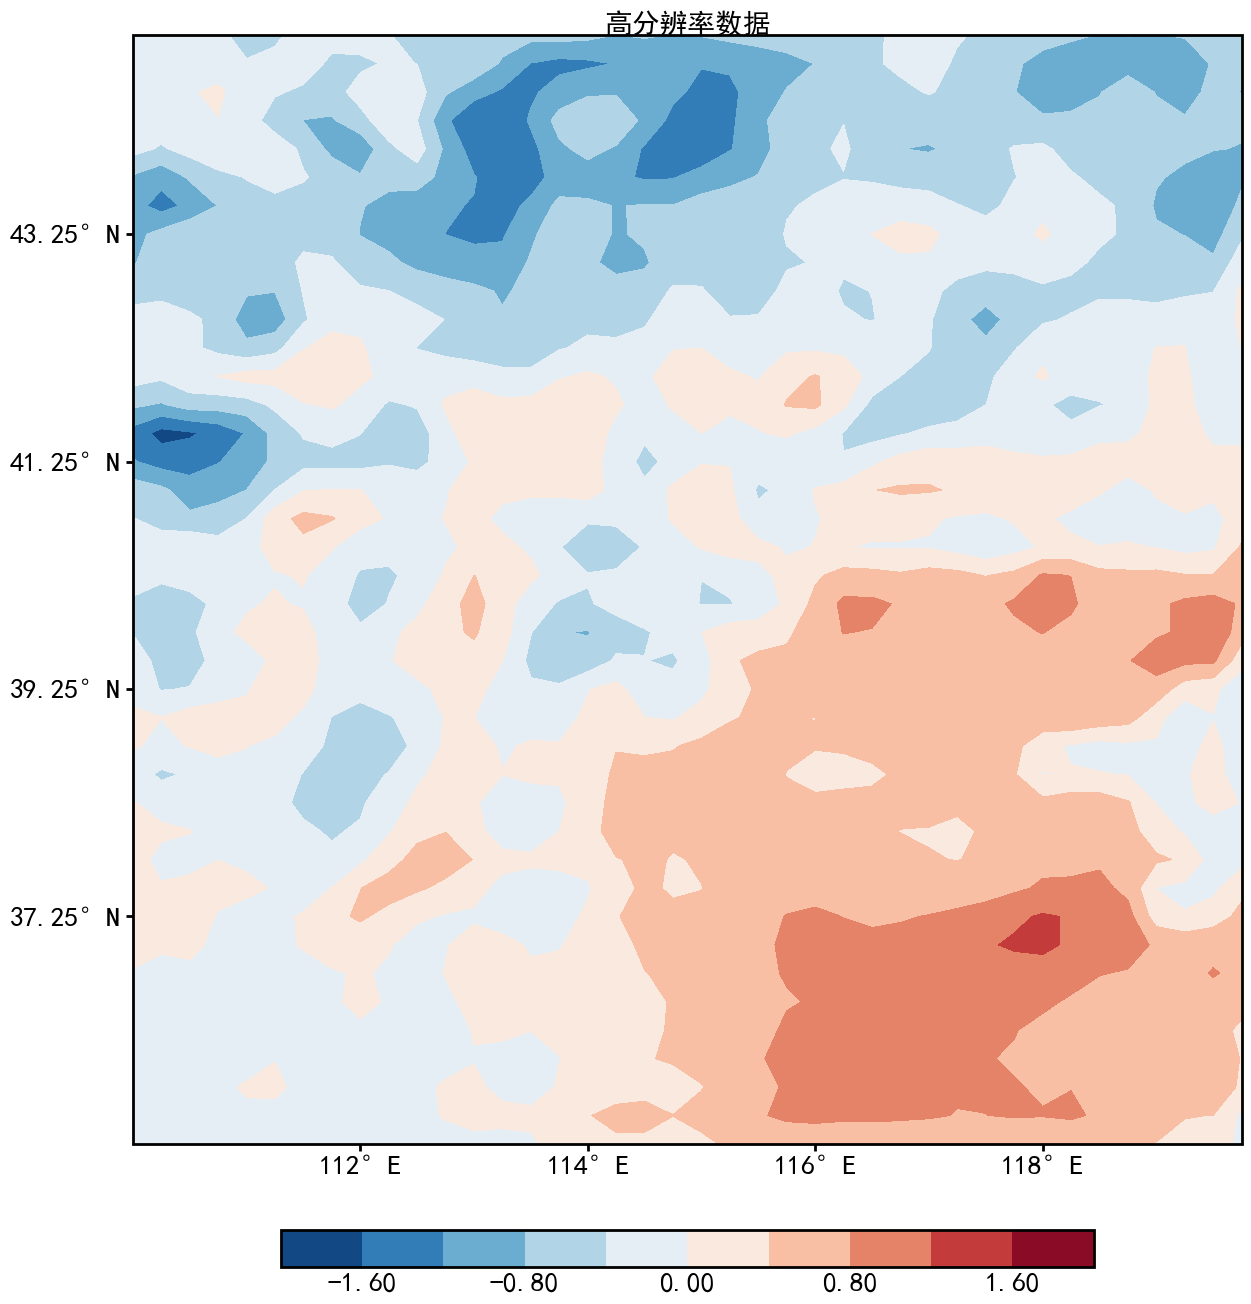

<Figure size 640x480 with 0 Axes>

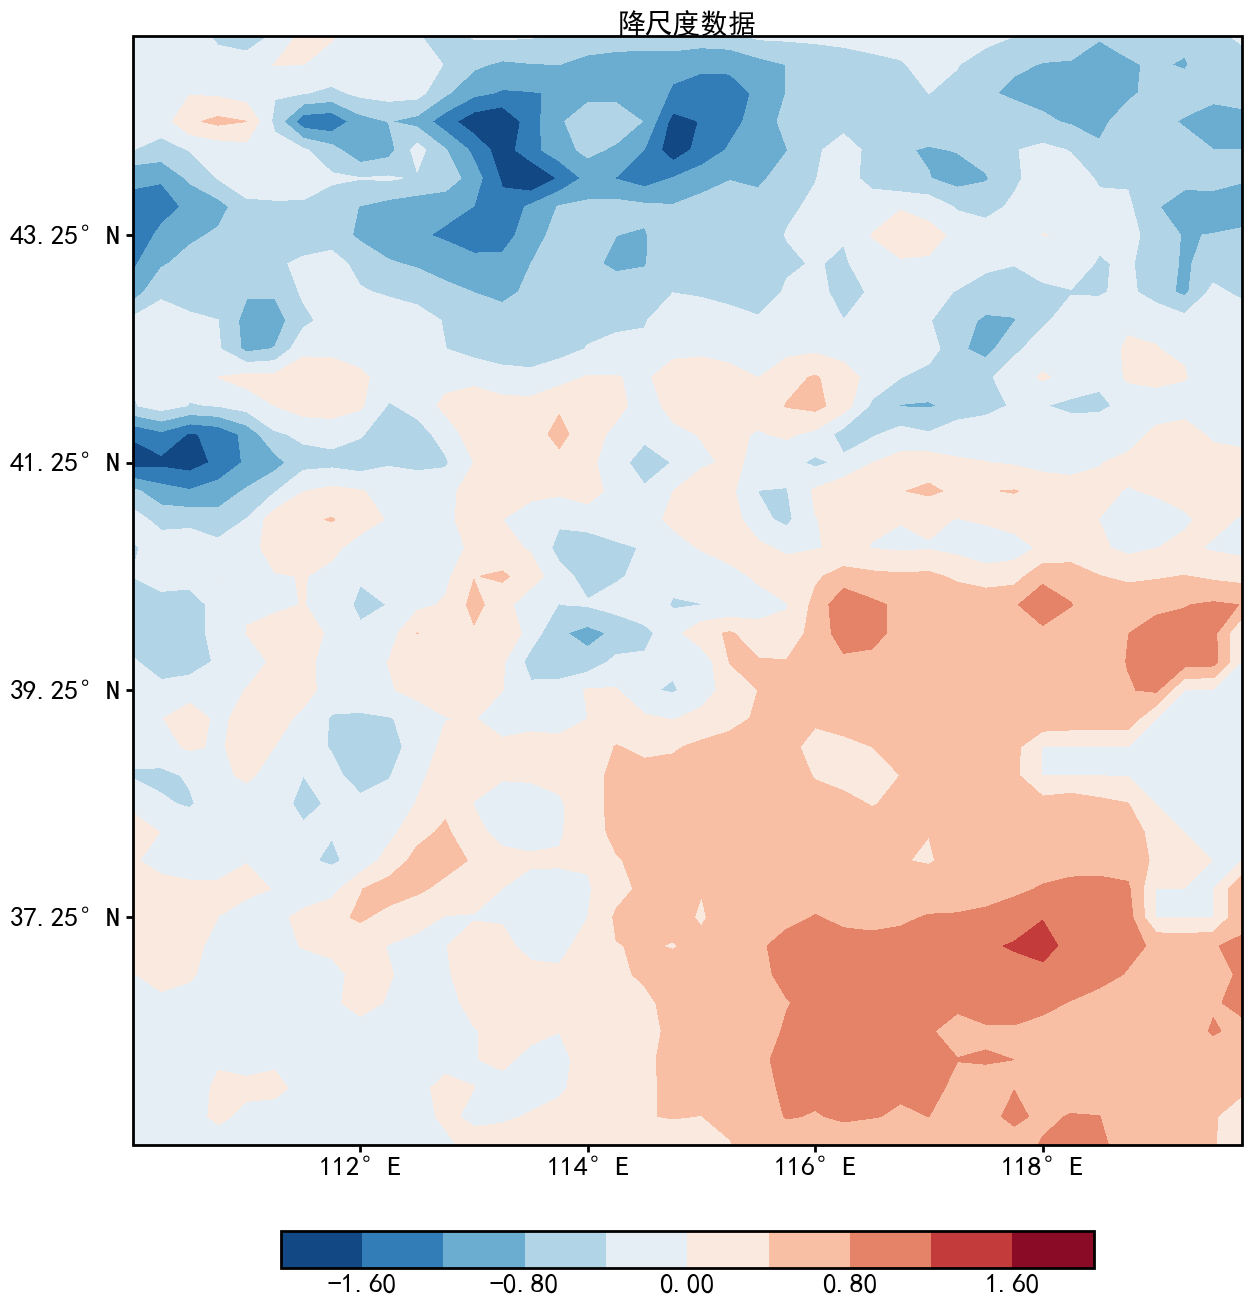

<Figure size 640x480 with 0 Axes>

In [8]:
import Auto_paint_self
Auto_paint_self.Autoshaded_quiver(testy[0,:,:],None,None,None,lon,lat,None,None,latlow,lattop,lonleft,lonright,'shaded','xy',picturenum=1,row=1,column=1,dpi=600,shadedcolor=None,ifshp='no',shpname=None,ifsave='no',savename=None,valuemodel='+-',ifself_vmax_vmin='yes',selfvmax =2.0,selfvmin=-2.0,shaded_quiver_title='高分辨率数据',ifline='no',ifclabel='no',ifcolorbar='yes',ifhatch='no',hatchpoint=None,hatchvalue=None,quiverscale=1,xspace=2,yspace=2,zspace=10000,labelsize=20,section=10.0,ifmaskout='no',maskoutarea=None,iftangle='no',tangle=None,ifchina='no',chinamap=None,ifsouthseamap='no',southseamap=None,southsealoc=[0.8, 0.21, 0.1, 0.15],ifglobal='no',projection_mode='plate',ifgridline='no',ifgeo='no',geo=None)
Auto_paint_self.Autoshaded_quiver(predicty[0,:,:],None,None,None,lon,lat,None,None,latlow,lattop,lonleft,lonright,'shaded','xy',picturenum=1,row=1,column=1,dpi=600,shadedcolor=None,ifshp='no',shpname=None,ifsave='no',savename=None,valuemodel='+-',ifself_vmax_vmin='yes',selfvmax =2.0,selfvmin=-2.0,shaded_quiver_title='降尺度数据',ifline='no',ifclabel='no',ifcolorbar='yes',ifhatch='no',hatchpoint=None,hatchvalue=None,quiverscale=1,xspace=2,yspace=2,zspace=10000,labelsize=20,section=10.0,ifmaskout='no',maskoutarea=None,iftangle='no',tangle=None,ifchina='no',chinamap=None,ifsouthseamap='no',southseamap=None,southsealoc=[0.8, 0.21, 0.1, 0.15],ifglobal='no',projection_mode='plate',ifgridline='no',ifgeo='no',geo=None)